# Notebook 2 — Détection d'Anomalies (Non Supervisé)
## Optimisation Énergétique BTS — Tunisie Telecom
**Prérequis : NB1 exécuté (`df_full_processed.parquet`, `config.joblib`)**

| Étape | Contenu |
|---|---|
| 0 | Imports |
| 1 | Chargement NB1 + validation colonnes QoS |
| 2 | Features d'anomalie + scalers |
| 2b | Estimation data-driven de la contamination |
| 3 | 7 modèles non supervisés (IF, LOF, SVM, DBSCAN, EE, GMM, AE) |
| 3b | Clustering K-Means + caractérisation QoS |
| 4 | Ensemble (vote + pondéré) + qualification QoS |
| 5 | Évaluation qualitative |
| 5b–5f | Validation métier, consensus, Jaccard, types, performance |
| 6 | Visualisations |
| 7 | Export NB3 |

In [4]:
import warnings
warnings.filterwarnings('ignore')

import os, json, time
import numpy  as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn.ensemble      import IsolationForest
from sklearn.neighbors     import LocalOutlierFactor, NearestNeighbors
from sklearn.svm           import OneClassSVM
from sklearn.cluster       import DBSCAN, KMeans
from sklearn.covariance    import EllipticEnvelope
from sklearn.mixture       import GaussianMixture
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from scipy.stats           import norm as sp_norm

import joblib

# TensorFlow (optionnel)
try:
    import tensorflow as tf
    HAS_TF = True
except ImportError:
    try:
        import subprocess, sys
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'tensorflow', '-q'])
        import tensorflow as tf
        HAS_TF = True
    except Exception:
        HAS_TF = False

# Statsmodels (z-test stabilité)
try:
    from statsmodels.stats.proportion import proportions_ztest
    HAS_STATSMODELS = True
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'statsmodels', '-q'])
    from statsmodels.stats.proportion import proportions_ztest
    HAS_STATSMODELS = True

os.makedirs('outputs', exist_ok=True)
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid', palette='muted')
print(f'imports ok | tensorflow: {HAS_TF} | statsmodels: {HAS_STATSMODELS}')

imports ok | tensorflow: True | statsmodels: True


In [5]:
df     = pd.read_parquet('/kaggle/input/datasets/benhadjalayamolka/outputnb1/df_full_processed.parquet')
config = joblib.load('/kaggle/input/datasets/benhadjalayamolka/outputnb1/config.joblib')

FEATURES  = config['features']
TARGET    = config['target']
qos_seuil = config.get('qos_seuil_optimisation', 0.60)

years = sorted(df['annee'].dropna().unique())
TEST_YEAR = years[-1]
df_train = df[df['annee'] < TEST_YEAR].copy()
df_test = df[df['annee'] == TEST_YEAR].copy()

COLS_QOS_REQUISES = ['score_qos', 'classe_qos', 'taux_charge_voix',
                     'taux_charge_data', 'stress_radio',
                     'score_qualite_radio', 'optimisation_qos_autorisee']
manquantes = [c for c in COLS_QOS_REQUISES if c not in df.columns]
if manquantes:
    raise RuntimeError(
        f"Colonnes QoS absentes du parquet NB1 : {manquantes}\n"
        "Relancer NB1 avec les indicateurs QoS activés."
    )

print(f'dataset : {df.shape}  |  train {len(df_train):,}  |  test {len(df_test):,}')
print(f'qos_seuil = {qos_seuil}')

dataset : (1577021, 93)  |  train 1,051,315  |  test 525,706
qos_seuil = 0.6


In [6]:
ANOM_COLS_CANDIDATES = [
    'ecart_pct', 'charge_cpu_pct', 'temperature_ambiante',
    'consommation_kwh', 'eei', 'ecart_vs_profil_horaire',
    'conso_moy_24h', 'tendance_3h',
]

ANOM_FEATURES = [c for c in ANOM_COLS_CANDIDATES if c in df.columns]
assert ANOM_FEATURES, "Aucune feature d'anomalie disponible."

# Médiane train-only pour imputation (évite data leakage + masquage outliers)
_medians_anom = df_train[ANOM_FEATURES].median()

def build_X(df_: pd.DataFrame, cols: list) -> np.ndarray:
    """Impute par médiane train → pas de 0 artificiels qui masquent les anomalies."""
    return df_[cols].fillna(_medians_anom[cols]).values

X_tr_raw  = build_X(df_train, ANOM_FEATURES)
X_te_raw  = build_X(df_test,  ANOM_FEATURES)
X_all_raw = build_X(df,       ANOM_FEATURES)

scaler_std = StandardScaler().fit(X_tr_raw)
scaler_rob = RobustScaler().fit(X_tr_raw)

X_tr_std  = scaler_std.transform(X_tr_raw)
X_te_std  = scaler_std.transform(X_te_raw)
X_all_std = scaler_std.transform(X_all_raw)

X_tr_rob  = scaler_rob.transform(X_tr_raw)
X_te_rob  = scaler_rob.transform(X_te_raw)
X_all_rob = scaler_rob.transform(X_all_raw)

print(f'features       : {ANOM_FEATURES}')
print(f'médiane imput. : {_medians_anom.round(3).to_dict()}')
print(f'train {X_tr_std.shape}  |  test {X_te_std.shape}')

features       : ['ecart_pct', 'charge_cpu_pct', 'temperature_ambiante', 'consommation_kwh', 'eei', 'ecart_vs_profil_horaire', 'conso_moy_24h', 'tendance_3h']
médiane imput. : {'ecart_pct': -0.737, 'charge_cpu_pct': 27.0, 'temperature_ambiante': 16.9, 'consommation_kwh': 3.033, 'eei': 100.0, 'ecart_vs_profil_horaire': 0.0, 'conso_moy_24h': 2.998, 'tendance_3h': 0.002}
train (1051315, 8)  |  test (525706, 8)


In [7]:
# Estimation data-driven de la contamination
# Principe : proportion d'observations dont l'écart absolu vs prédiction
# dépasse 2 IQR — robuste aux outliers, borné entre 1 % et 8 %.

if 'ecart_pct' in df.columns:
    ecarts = df_train['ecart_pct'].fillna(0).abs()
    q25, q75 = ecarts.quantile(0.25), ecarts.quantile(0.75)
    iqr = q75 - q25
    seuil_iqr = q75 + 2.0 * iqr
    CONTAMINATION = float(np.clip((ecarts > seuil_iqr).mean(), 0.01, 0.08))
else:
    CONTAMINATION = 0.03

print(f'contamination estimée : {CONTAMINATION:.4f}  ({CONTAMINATION*100:.2f} %)')

contamination estimée : 0.0643  (6.43 %)


In [8]:
anomalie_scores = {}
anomalie_labels = {}

print(f'entrainement des 7 modèles  (contamination = {CONTAMINATION:.3f})\n')

# Isolation Forest
t0 = time.time()
iso_f = IsolationForest(n_estimators=200, contamination=CONTAMINATION,
                        max_samples='auto', random_state=42, n_jobs=-1)
iso_f.fit(X_tr_std)
scores_iso = -iso_f.score_samples(X_all_std)
labels_iso = (iso_f.predict(X_all_std) == -1).astype(int)
anomalie_scores['Isolation Forest'] = {
    'train': -iso_f.score_samples(X_tr_std),
    'test':  -iso_f.score_samples(X_te_std),
    'all':   -iso_f.score_samples(X_all_std),
}
anomalie_labels['Isolation Forest'] = labels_iso
print(f'[IF]  {time.time()-t0:.1f}s  |  anomalies : {labels_iso.sum():,} ({labels_iso.mean()*100:.1f}%)')

# Local Outlier Factor  (sous-échantillonnage identique aux autres modèles)
t0     = time.time()
N_LOF  = min(50_000, len(X_tr_std))
idx_lof = np.random.RandomState(42).choice(len(X_tr_std), N_LOF, replace=False)
lof = LocalOutlierFactor(n_neighbors=20, contamination=CONTAMINATION,
                         novelty=True, n_jobs=-1)
lof.fit(X_tr_std[idx_lof])
labels_lof = (lof.predict(X_all_std) == -1).astype(int)
anomalie_scores['LOF'] = {
    'train': -lof.score_samples(X_tr_std),
    'test':  -lof.score_samples(X_te_std),
    'all': -lof.score_samples(X_all_std),

}
anomalie_labels['LOF'] = labels_lof
print(f'[LOF] {time.time()-t0:.1f}s  |  anomalies : {labels_lof.sum():,} ({labels_lof.mean()*100:.1f}%)')

# One-Class SVM
t0 = time.time()
N_OC   = min(30_000, len(X_tr_std))
idx_oc = np.random.RandomState(42).choice(len(X_tr_std), N_OC, replace=False)
oc_svm = OneClassSVM(nu=CONTAMINATION, kernel='rbf', gamma='scale')
oc_svm.fit(X_tr_std[idx_oc])
labels_ocsvm = (oc_svm.predict(X_all_std) == -1).astype(int)
anomalie_scores['One-Class SVM'] = {
    'train': -oc_svm.score_samples(X_tr_std),
    'test':  -oc_svm.score_samples(X_te_std),
    'all': -oc_svm.score_samples(X_all_std),
}
anomalie_labels['One-Class SVM'] = labels_ocsvm
print(f'[SVM] {time.time()-t0:.1f}s  |  anomalies : {labels_ocsvm.sum():,} ({labels_ocsvm.mean()*100:.1f}%)')

# DBSCAN
t0 = time.time()
pca_db    = PCA(n_components=4, random_state=42).fit(X_tr_std)
X_all_pca = pca_db.transform(X_all_std)

N_DB   = min(50_000, len(X_all_pca))
idx_db = np.random.RandomState(42).choice(len(X_all_pca), N_DB, replace=False)

#  Calibration automatique de eps
MIN_SAMPLES_DB = 10
_knn_eps  = NearestNeighbors(n_neighbors=MIN_SAMPLES_DB, n_jobs=-1).fit(X_all_pca[idx_db])
_k_dists  = np.sort(_knn_eps.kneighbors(X_all_pca[idx_db])[0][:, -1])
EPS_AUTO  = float(np.percentile(_k_dists, 95))
print(f'         eps calibré : {EPS_AUTO:.4f}')

db = DBSCAN(eps=EPS_AUTO, min_samples=MIN_SAMPLES_DB, n_jobs=-1)
labels_db_sub = db.fit_predict(X_all_pca[idx_db])
anom_sub      = (labels_db_sub == -1).astype(int)

# Propagation labels vers points hors sous-ensemble
mask_unseen   = np.ones(len(X_all_pca), dtype=bool)
mask_unseen[idx_db] = False
labels_dbscan = np.zeros(len(X_all_pca), dtype=int)
labels_dbscan[idx_db] = anom_sub

knn_score_db = NearestNeighbors(n_neighbors=2, n_jobs=-1).fit(X_all_pca[idx_db])
dist_all_db_raw, nn_idx_all = knn_score_db.kneighbors(X_all_pca)
# Pour les points dans idx_db, le 1er voisin est eux-mêmes (dist≈0) → prendre le 2ème
dist_all_db = dist_all_db_raw[:, 1].reshape(-1, 1) # 2ème voisin pour idx_db
# Pour les points hors idx_db, le 1er voisin est correct
mask_in_sub = np.zeros(len(X_all_pca), dtype=bool)
mask_in_sub[idx_db] = True
dist_all_db[~mask_in_sub] = dist_all_db_raw[~mask_in_sub, 0:1]
if mask_unseen.sum() > 0:
    labels_dbscan[mask_unseen] = anom_sub[nn_idx_all[mask_unseen, 0]]  # 1er voisin uniquement

#Score continu = distance au plus proche voisin (plus loin = plus anormal)
scores_dbscan = dist_all_db.ravel()

anomalie_scores['DBSCAN'] = {
    'train': scores_dbscan[:len(X_tr_std)],
    'test':  scores_dbscan[len(X_tr_std):],
    'all':   scores_dbscan,
}
anomalie_labels['DBSCAN'] = labels_dbscan
print(f'[DB]  {time.time()-t0:.1f}s  |  anomalies : {labels_dbscan.sum():,} ({labels_dbscan.mean()*100:.1f}%)')

# Elliptic Envelope
t0 = time.time()
N_EE   = min(50_000, len(X_tr_std))
idx_ee = np.random.RandomState(42).choice(len(X_tr_std), N_EE, replace=False)
EE_SUPPORT = round(max(0.75, 1.0 - CONTAMINATION - 0.05), 3)
print(f'         EE support_fraction : {EE_SUPPORT}')
ee = EllipticEnvelope(contamination=CONTAMINATION,
                       support_fraction=EE_SUPPORT, random_state=42)
ee.fit(X_tr_std[idx_ee])
labels_ee = (ee.predict(X_all_std) == -1).astype(int)
anomalie_scores['Elliptic Envelope'] = {
    'train': -ee.score_samples(X_tr_std),
    'test':  -ee.score_samples(X_te_std),
    'all':   -ee.score_samples(X_all_std),
}
anomalie_labels['Elliptic Envelope'] = labels_ee
print(f'[EE]  {time.time()-t0:.1f}s  |  anomalies : {labels_ee.sum():,} ({labels_ee.mean()*100:.1f}%)')

#  Gaussian Mixture Model
t0 = time.time()
N_GMM   = min(50_000, len(X_tr_std))
idx_gmm = np.random.RandomState(42).choice(len(X_tr_std), N_GMM, replace=False)
gmm     = GaussianMixture(n_components=5, covariance_type='full',
                          random_state=42, max_iter=200)
gmm.fit(X_tr_std[idx_gmm])
scores_gmm = -gmm.score_samples(X_all_std)
seuil_gmm  = np.percentile(scores_gmm[:len(X_tr_std)], (1 - CONTAMINATION) * 100)
labels_gmm = (scores_gmm > seuil_gmm).astype(int)
anomalie_scores['GMM'] = {
    'train': scores_gmm[:len(X_tr_std)],
    'test':  scores_gmm[len(X_tr_std):],
    'all':   scores_gmm,
}
anomalie_labels['GMM'] = labels_gmm
print(f'[GMM] {time.time()-t0:.1f}s  |  anomalies : {labels_gmm.sum():,} ({labels_gmm.mean()*100:.1f}%)')

# Autoencoder
t0 = time.time()
if HAS_TF:
    from tensorflow.keras import layers, Model, callbacks as tf_cb
    n_feat  = X_tr_std.shape[1]
    inp     = tf.keras.Input(shape=(n_feat,))
    x       = layers.Dense(32, activation='relu')(inp)
    x       = layers.Dense(16, activation='relu')(x)
    bottleneck = layers.Dense(8, activation='relu')(x)
    x       = layers.Dense(16, activation='relu')(bottleneck)
    x       = layers.Dense(32, activation='relu')(x)
    out     = layers.Dense(n_feat, activation='linear')(x)
    ae      = Model(inp, out)
    ae.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse')

    N_AE   = min(100_000, len(X_tr_std))
    idx_ae = np.random.RandomState(42).choice(len(X_tr_std), N_AE, replace=False)

    es = tf_cb.EarlyStopping(monitor='val_loss', patience=5,
                              restore_best_weights=True, verbose=0)
    lr = tf_cb.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                  patience=3, verbose=0)
    ae.fit(X_tr_std[idx_ae], X_tr_std[idx_ae],
           epochs=50, batch_size=512, validation_split=0.1,
           callbacks=[es, lr], verbose=0)

    recon_all = ae.predict(X_all_std, verbose=0)
    scores_ae = np.mean((X_all_std - recon_all) ** 2, axis=1)
    seuil_ae  = np.percentile(scores_ae[:len(X_tr_std)], (1 - CONTAMINATION) * 100)
    labels_ae = (scores_ae > seuil_ae).astype(int)
    AE_KEY    = 'Autoencoder'
else:
    pca_ae    = PCA(n_components=3, random_state=42).fit(X_tr_std)
    recon_all = pca_ae.inverse_transform(pca_ae.transform(X_all_std))
    scores_ae = np.mean((X_all_std - recon_all) ** 2, axis=1)
    seuil_ae  = np.percentile(scores_ae[:len(X_tr_std)], (1 - CONTAMINATION) * 100)
    labels_ae = (scores_ae > seuil_ae).astype(int)
    AE_KEY    = 'PCA Reconstruction'
    pca_ae_model = pca_ae

anomalie_scores[AE_KEY] = {
    'train': scores_ae[:len(X_tr_std)],
    'test':  scores_ae[len(X_tr_std):],
    'all': scores_ae,
}
anomalie_labels[AE_KEY] = labels_ae
print(f'[AE]  {time.time()-t0:.1f}s  |  anomalies : {labels_ae.sum():,} ({labels_ae.mean()*100:.1f}%)')



entrainement des 7 modèles  (contamination = 0.064)

[IF]  61.2s  |  anomalies : 101,611 (6.4%)
[LOF] 290.4s  |  anomalies : 110,161 (7.0%)
[SVM] 415.6s  |  anomalies : 104,712 (6.6%)
         eps calibré : 0.6255
[DB]  10.6s  |  anomalies : 46,874 (3.0%)
         EE support_fraction : 0.886
[EE]  4.5s  |  anomalies : 104,814 (6.6%)
[GMM] 5.8s  |  anomalies : 98,251 (6.2%)


I0000 00:00:1779302019.749737      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779302019.755819      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1779302023.661831     214 service.cc:152] XLA service 0x7f0a44004d90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779302023.661874     214 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779302023.661878     214 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779302024.203097     214 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1779302025.924412     214 device_compiler.h:188] Compiled clust

[AE]  150.9s  |  anomalies : 95,176 (6.0%)


In [9]:
cols_cluster = [c for c in ['consommation_kwh', 'score_qos',
                              'taux_charge_voix', 'taux_charge_data',
                              'stress_radio'] if c in df.columns]

assert cols_cluster, "Aucune colonne de clustering disponible — vérifier que NB1 a bien exporté les colonnes QoS."

scaler_clust = StandardScaler().fit(df[cols_cluster].fillna(0))
X_clust      = scaler_clust.transform(df[cols_cluster].fillna(0))

kmeans           = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster_id'] = kmeans.fit_predict(X_clust)
conso_med        = df['consommation_kwh'].median()

agg_dict = {
    'conso_moy'     : ('consommation_kwh', 'mean'),
    'n_obs'         : ('consommation_kwh', 'count'),
    'score_qos_moy' : ('score_qos', 'mean'),
    'pct_critique'  : ('classe_qos', lambda x: (x == 'Critique').mean() * 100),
}
cluster_profile = df.groupby('cluster_id').agg(**agg_dict).round(3)

def nommer_cluster(row):
    haute  = row['conso_moy'] > conso_med
    bonne  = row['score_qos_moy'] >= qos_seuil
    if haute and bonne:      return 'A — charge_legitime'
    if haute and not bonne:  return 'B — anomalie_prioritaire'
    if not haute and bonne:  return 'C — sous_utilise'
    return                          'D — degrade_faible_charge'

cluster_profile['nom_operationnel'] = cluster_profile.apply(nommer_cluster, axis=1)
cluster_nom_map = cluster_profile['nom_operationnel'].to_dict()
df['cluster_nom'] = df['cluster_id'].map(cluster_nom_map)

print(cluster_profile.to_string())

            conso_moy   n_obs  score_qos_moy  pct_critique           nom_operationnel
cluster_id                                                                           
0               4.638  333071          0.657         0.050        A — charge_legitime
1               2.054  192565          0.363        48.869  D — degrade_faible_charge
2               2.086  506498          0.878         0.000           C — sous_utilise
3               3.862  544887          0.857         0.000        A — charge_legitime


In [10]:
def normaliser_min_max(arr):
    mn, mx = arr.min(), arr.max()
    return (arr - mn) / (mx - mn + 1e-9)

score_matrix  = {}
labels_matrix = pd.DataFrame(anomalie_labels)


for nom, d in anomalie_scores.items():
    all_scores        = d['all']
    score_matrix[nom] = normaliser_min_max(all_scores)

df_scores = pd.DataFrame(score_matrix, index=df.index)

# Vote majoritaire
seuil_vote = len(anomalie_labels) // 2
votes      = labels_matrix.sum(axis=1)
label_vote = (votes >= seuil_vote).astype(int)

# Score moyen
score_moyen  = df_scores.mean(axis=1)
seuil_moyen  = score_moyen.quantile(1 - CONTAMINATION)
label_moyen  = (score_moyen > seuil_moyen).astype(int)

# Score pondéré — poids data-driven
_ecart_cible = {
    nom: max(0.01, 1.0 - abs(pd.Series(lbl).mean() - CONTAMINATION) * 10)
    for nom, lbl in anomalie_labels.items()
    if nom in df_scores.columns
}
_total_ecart = sum(_ecart_cible.values())
POIDS = {nom: round(v / _total_ecart, 4) for nom, v in _ecart_cible.items()}
print('Poids data-driven :')
for k, v in sorted(POIDS.items(), key=lambda x: -x[1]):
    print(f'  {k:<22} {v:.4f}')


score_pondere = pd.Series(np.zeros(len(df)), index=df.index)
total_poids   = 0.0
for nom, p in POIDS.items():
    if nom in df_scores.columns:
        score_pondere += df_scores[nom] * p
        total_poids   += p
score_pondere /= total_poids

seuil_pondere = score_pondere.quantile(1 - CONTAMINATION)
label_pondere = (score_pondere > seuil_pondere).astype(int)

df['anomalie_score_ensemble'] = score_pondere.values
df['nb_votes_anomalie']       = votes.values
df['label_ensemble_vote']     = label_vote.values
df['label_ensemble_score']    = label_pondere.values
df['niveau_anomalie']         = (
    (df['nb_votes_anomalie'] >= 2).astype(int) +
    (df['nb_votes_anomalie'] >= seuil_vote).astype(int)
)

# Qualification QoS
if 'hors_intervalle' not in df.columns:
    df['hors_intervalle'] = label_pondere.values

df['anomalie_prioritaire'] = (
    (df['hors_intervalle'] == 1) & (df['score_qos'] < qos_seuil)
).astype(int)

df['anomalie_energetique_pure'] = (
    (df['hors_intervalle'] == 1) & (df['score_qos'] >= qos_seuil)
).astype(int)

print(f'\nvote majoritaire (>={seuil_vote})  : {label_vote.sum():,} anomalies ({label_vote.mean()*100:.1f}%)')
print(f'score moyen (top {CONTAMINATION*100:.1f}%)        : {label_moyen.sum():,} anomalies')
print(f'score pondéré (top {CONTAMINATION*100:.1f}%)      : {label_pondere.sum():,} anomalies')
print()
print(f'anomalie_prioritaire       : {df["anomalie_prioritaire"].sum():,}')
print(f'anomalie_energetique_pure  : {df["anomalie_energetique_pure"].sum():,}')

Poids data-driven :
  Isolation Forest       0.1537
  GMM                    0.1509
  One-Class SVM          0.1507
  Elliptic Envelope      0.1506
  Autoencoder            0.1479
  LOF                    0.1454
  DBSCAN                 0.1008

vote majoritaire (>=3)  : 92,210 anomalies (5.8%)
score moyen (top 6.4%)        : 101,374 anomalies
score pondéré (top 6.4%)      : 101,374 anomalies

anomalie_prioritaire       : 55,193
anomalie_energetique_pure  : 283,623


In [11]:
# Référence métier : ecart_pct > 30 %
label_ref = (df['ecart_pct'].fillna(0).abs() > 30).astype(int)

resultats_qual = {}
for nom, lbl in anomalie_labels.items():
    lbl_s       = pd.Series(lbl, index=df.index)   # doit être défini en premier
    mask_train  = df['annee'] < TEST_YEAR
    n_anom  = int(lbl_s.sum())
    pct_all = lbl_s.mean() * 100
    n_tr    = len(df_train)
    pct_tr      = lbl_s[mask_train].mean() * 100
    pct_te      = lbl_s[~mask_train].mean() * 100

    accord  = (lbl_s == label_ref.values).mean() * 100 if label_ref.sum() > 0 else None
    resultats_qual[nom] = {
        'n_anomalies'     : n_anom,
        'pct_anomalies'   : round(pct_all, 2),
        'pct_train'       : round(pct_tr, 2),
        'pct_test'        : round(pct_te, 2),
        'instabilite'     : round(abs(pct_tr - pct_te), 2),
        'accord_metier_%' : round(accord, 1) if accord else 'N/A',
    }

df_qual = pd.DataFrame(resultats_qual).T.sort_values('pct_anomalies')
print(df_qual.to_string())

                   n_anomalies  pct_anomalies  pct_train  pct_test  instabilite  accord_metier_%
DBSCAN                 46874.0           2.97       2.97      2.97         0.00             97.3
Autoencoder            95176.0           6.04       5.99      6.13         0.14             91.5
GMM                    98251.0           6.23       6.23      6.23         0.01             94.8
Isolation Forest      101611.0           6.44       6.43      6.47         0.05             94.3
One-Class SVM         104712.0           6.64       6.63      6.67         0.04             94.1
Elliptic Envelope     104814.0           6.65       6.59      6.76         0.16             95.9
LOF                   110161.0           6.99       6.86      7.23         0.36             90.4


                   n_anomalies  pct_detection  valid_regle_ecart_30pct  valid_regle_qos_degrade  valid_regle_conso_q95  valid_regle_eei_eleve  valid_regle_combinee  score_validation_global
DBSCAN                 46874.0           2.97                     69.3                     19.5                   34.8                   44.0                  14.1                     36.3
Isolation Forest      101611.0           6.44                     35.9                     29.2                   30.0                   36.3                   6.7                     27.6
One-Class SVM         104712.0           6.64                     35.1                     22.9                   24.0                   31.9                   6.8                     24.1
GMM                    98251.0           6.23                     39.4                     22.1                   22.1                   28.7                   7.5                     24.0
Elliptic Envelope     104814.0           6.65          

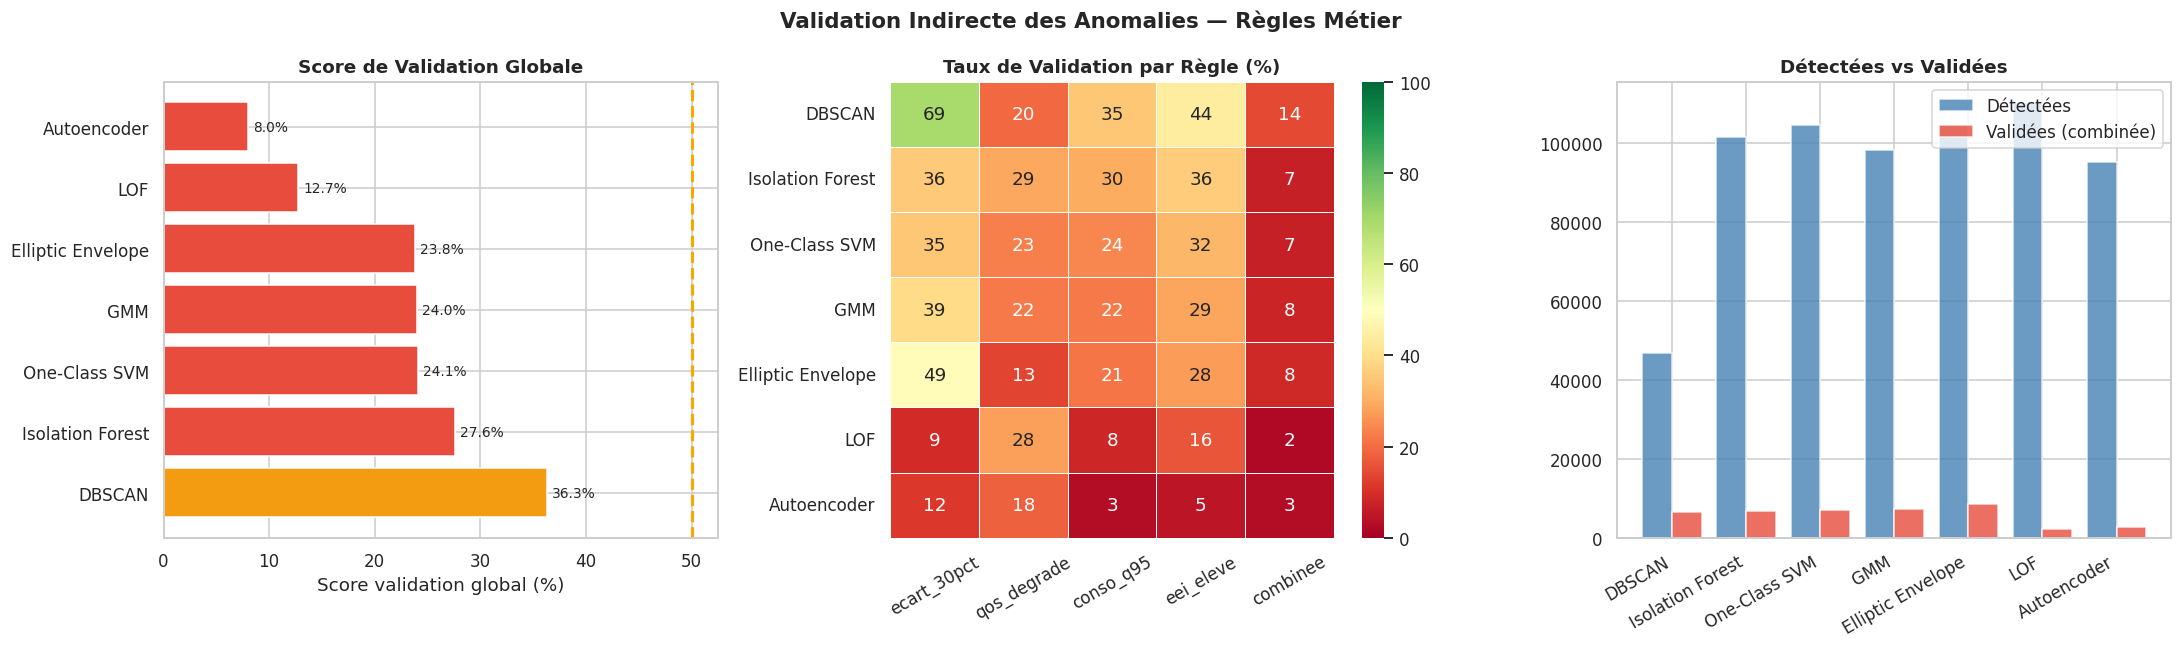

In [12]:
regles = {}
if 'ecart_pct' in df.columns:
    regles['regle_ecart_30pct']  = (df['ecart_pct'].fillna(0).abs() > 30).astype(int)
regles['regle_qos_degrade']  = (df['score_qos'] < qos_seuil).astype(int)
q95_conso = df['consommation_kwh'].quantile(0.95)
regles['regle_conso_q95']    = (df['consommation_kwh'] > q95_conso).astype(int)
if 'eei' in df.columns:
    regles['regle_eei_eleve'] = (df['eei'] > df['eei'].quantile(0.90)).astype(int)
if 'regle_ecart_30pct' in regles:
    regles['regle_combinee'] = (
        (regles['regle_ecart_30pct'] == 1) & (regles['regle_qos_degrade'] == 1)
    ).astype(int)

df_regles = pd.DataFrame(regles, index=df.index)

validation_metier = {}
for nom, lbl in anomalie_labels.items():
    lbl_s  = pd.Series(lbl, index=df.index)
    n_anom = lbl_s.sum()
    row    = {'n_anomalies': int(n_anom), 'pct_detection': round(lbl_s.mean()*100, 2)}
    for rnom, rvals in df_regles.items():
        row[f'valid_{rnom}'] = round((lbl_s & rvals).sum() / max(n_anom, 1) * 100, 1)
    vcols = [v for k, v in row.items() if k.startswith('valid_')]
    row['score_validation_global'] = round(float(np.mean(vcols)), 1)
    validation_metier[nom] = row

df_validation = pd.DataFrame(validation_metier).T.sort_values('score_validation_global', ascending=False)
print(df_validation.to_string())

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Validation Indirecte des Anomalies — Règles Métier', fontsize=14, fontweight='bold')

mods_v = df_validation.index.tolist()
scrs_v = df_validation['score_validation_global'].values
cols_v = ['#2ecc71' if s >= 50 else '#f39c12' if s >= 30 else '#e74c3c' for s in scrs_v]
axes[0].barh(mods_v, scrs_v, color=cols_v)
axes[0].axvline(50, color='orange', ls='--', lw=2)
axes[0].set_xlabel('Score validation global (%)')
axes[0].set_title('Score de Validation Globale', fontweight='bold')
for i, (s, _) in enumerate(zip(scrs_v, mods_v)):
    axes[0].text(s + 0.5, i, f'{s:.1f}%', va='center', fontsize=9)

vcols_names = [c for c in df_validation.columns if c.startswith('valid_')]
if vcols_names:
    df_hm = df_validation[vcols_names].copy()
    df_hm.columns = [c.replace('valid_regle_', '') for c in df_hm.columns]
    sns.heatmap(df_hm.astype(float), ax=axes[1], annot=True, fmt='.0f',
                cmap='RdYlGn', vmin=0, vmax=100, linewidths=0.5)
    axes[1].set_title('Taux de Validation par Règle (%)', fontweight='bold')
    axes[1].tick_params(axis='x', rotation=30)

if 'regle_combinee' in df_regles.columns:
    n_det  = [validation_metier[m]['n_anomalies'] for m in mods_v]
    n_val  = [(anomalie_labels[m] & df_regles['regle_combinee'].values).sum() for m in mods_v]
    xp     = np.arange(len(mods_v))
    axes[2].bar(xp - 0.2, n_det, 0.4, label='Détectées',          color='steelblue', alpha=0.8)
    axes[2].bar(xp + 0.2, n_val, 0.4, label='Validées (combinée)', color='#e74c3c',  alpha=0.8)
    axes[2].set_xticks(xp)
    axes[2].set_xticklabels(mods_v, rotation=30, ha='right')
    axes[2].set_title('Détectées vs Validées', fontweight='bold')
    axes[2].legend()

plt.tight_layout()
plt.show()

                 consommation_kwh        score_qos        ecart_pct             eei         
                             mean median      mean median      mean median     mean   median
consensus_niveau                                                                            
Normal                      3.189  3.010     0.769  0.842    -1.052 -0.848  102.397   99.615
Bruit (1-2)                 3.117  3.035     0.726  0.815    -1.064 -0.395  100.128  100.633
Moyen (3-4)                 3.470  3.617     0.728  0.794    -6.622 -0.707  101.256  105.148
Fort (>=5)                  4.762  4.366     0.724  0.788    24.902  2.735  144.498  131.737


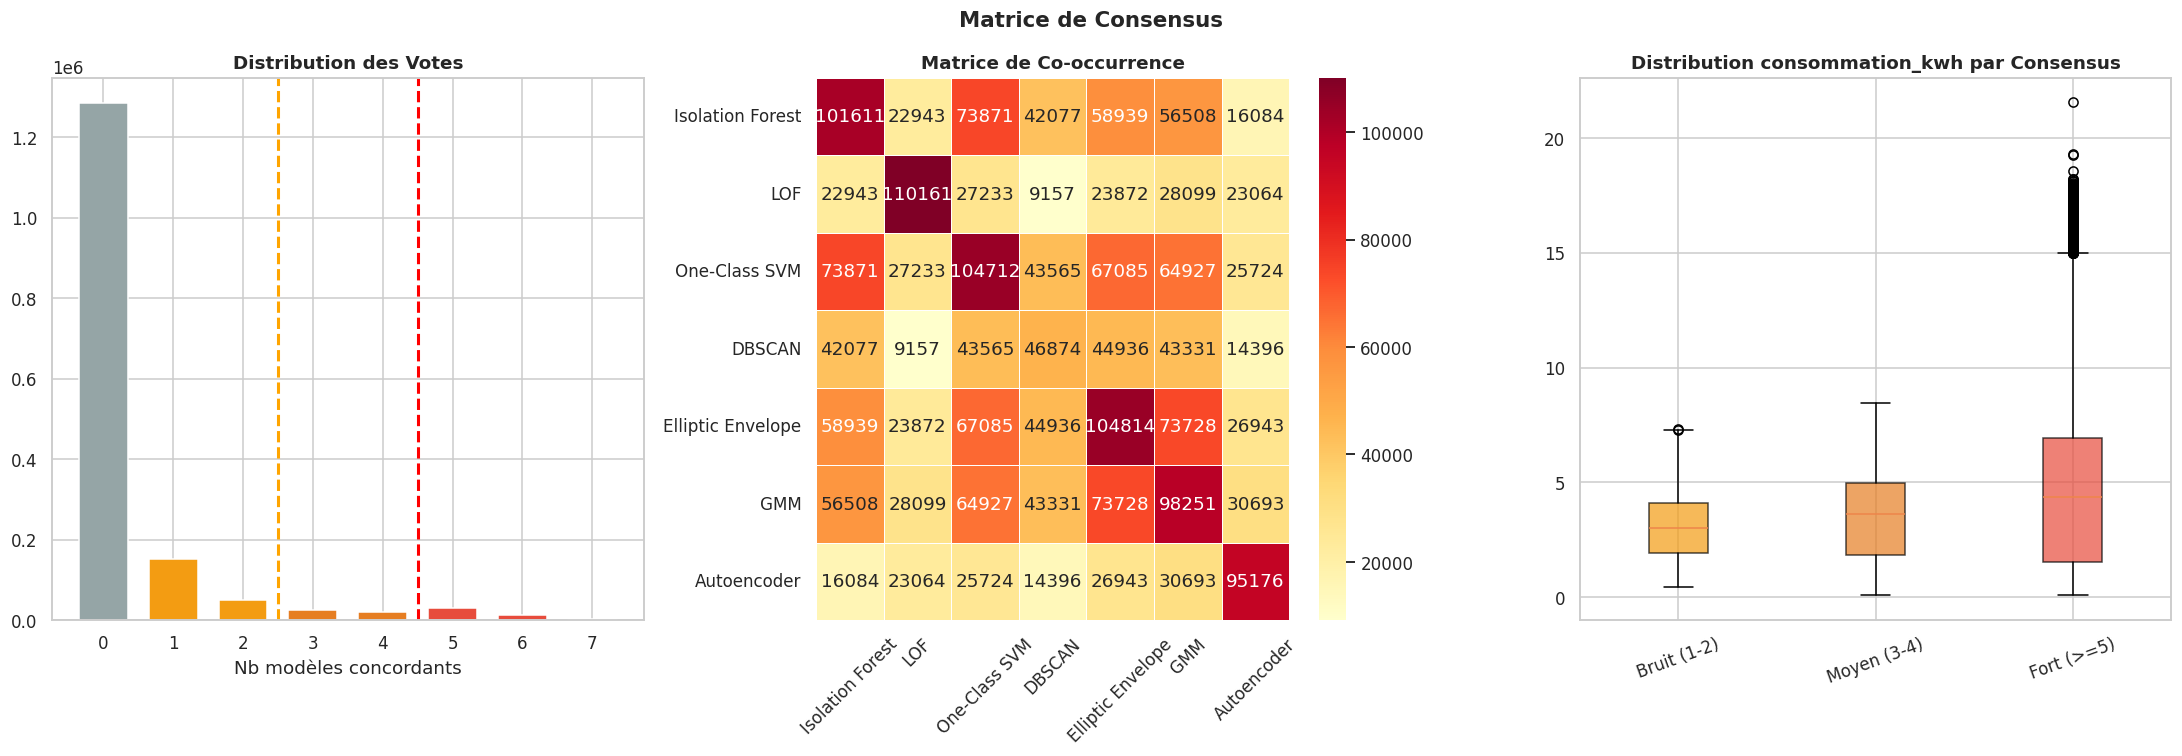

fort  (>=5) : 47,411  (3.01%)
moyen          : 44,799  (2.84%)
bruit          : 201,370  (12.77%)


In [13]:
n_modeles       = len(anomalie_labels)
labels_mat      = pd.DataFrame(anomalie_labels, index=df.index)
consensus_votes = labels_mat.sum(axis=1)

seuil_fort  = max(3, int(np.ceil(n_modeles * 0.70)))
seuil_moyen = max(2, int(np.ceil(n_modeles * 0.40)))

df['consensus_votes']  = consensus_votes.values
df['consensus_niveau'] = pd.cut(
    consensus_votes,
    bins  = [-1, 0, seuil_moyen-1, seuil_fort-1, n_modeles],
    labels= ['Normal',
             f'Bruit (1-{seuil_moyen-1})',
             f'Moyen ({seuil_moyen}-{seuil_fort-1})',
             f'Fort (>={seuil_fort})']
)

cols_profil = [c for c in ['consommation_kwh', 'score_qos', 'ecart_pct', 'eei'] if c in df.columns]
print(df.groupby('consensus_niveau', observed=True)[cols_profil].agg(['mean', 'median']).round(3).to_string())

modele_noms = list(anomalie_labels.keys())
n_m         = len(modele_noms)
co_matrix   = np.zeros((n_m, n_m), dtype=int)
for i, m1 in enumerate(modele_noms):
    for j, m2 in enumerate(modele_noms):
        co_matrix[i, j] = (labels_mat[m1] & labels_mat[m2]).sum()
df_comat = pd.DataFrame(co_matrix, index=modele_noms, columns=modele_noms)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Matrice de Consensus', fontsize=14, fontweight='bold')

vote_counts = consensus_votes.value_counts().sort_index()
bar_colors  = ['#95a5a6' if v == 0 else '#f39c12' if v < seuil_moyen
               else '#e67e22' if v < seuil_fort else '#e74c3c'
               for v in vote_counts.index]
axes[0].bar(vote_counts.index, vote_counts.values, color=bar_colors, edgecolor='white', width=0.7)
axes[0].axvline(seuil_fort  - 0.5, color='red',    ls='--', lw=2)
axes[0].axvline(seuil_moyen - 0.5, color='orange', ls='--', lw=2)
axes[0].set_title('Distribution des Votes', fontweight='bold')
axes[0].set_xlabel('Nb modèles concordants')

sns.heatmap(df_comat, ax=axes[1], annot=True, fmt='d',
            cmap='YlOrRd', linewidths=0.5)
axes[1].set_title('Matrice de Co-occurrence', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

col_box = 'consommation_kwh' if 'consommation_kwh' in df.columns else cols_profil[0]
df_box  = df[['consensus_niveau', col_box]].dropna()
df_box_anom = df_box[df_box['consensus_niveau'] != 'Normal']
data_bp  = [df_box_anom[df_box_anom['consensus_niveau'] == n][col_box].dropna().values
            for n in df_box_anom['consensus_niveau'].cat.categories if n != 'Normal']
labs_bp  = [str(n) for n in df_box_anom['consensus_niveau'].cat.categories if n != 'Normal']
data_bp, labs_bp = zip(*[(d, l) for d, l in zip(data_bp, labs_bp) if len(d) > 0]) if data_bp else ([], [])
if data_bp:
    bp = axes[2].boxplot(list(data_bp), labels=list(labs_bp), patch_artist=True)
    for patch, c in zip(bp['boxes'], ['#f39c12', '#e67e22', '#e74c3c'][:len(bp['boxes'])]):
        patch.set_facecolor(c); patch.set_alpha(0.7)
axes[2].set_title(f'Distribution {col_box} par Consensus', fontweight='bold')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

n_fort  = (consensus_votes >= seuil_fort).sum()
n_moyen = ((consensus_votes >= seuil_moyen) & (consensus_votes < seuil_fort)).sum()
n_bruit = ((consensus_votes >= 1) & (consensus_votes < seuil_moyen)).sum()
print(f'fort  (>={seuil_fort}) : {n_fort:,}  ({n_fort/len(df)*100:.2f}%)')
print(f'moyen          : {n_moyen:,}  ({n_moyen/len(df)*100:.2f}%)')
print(f'bruit          : {n_bruit:,}  ({n_bruit/len(df)*100:.2f}%)')

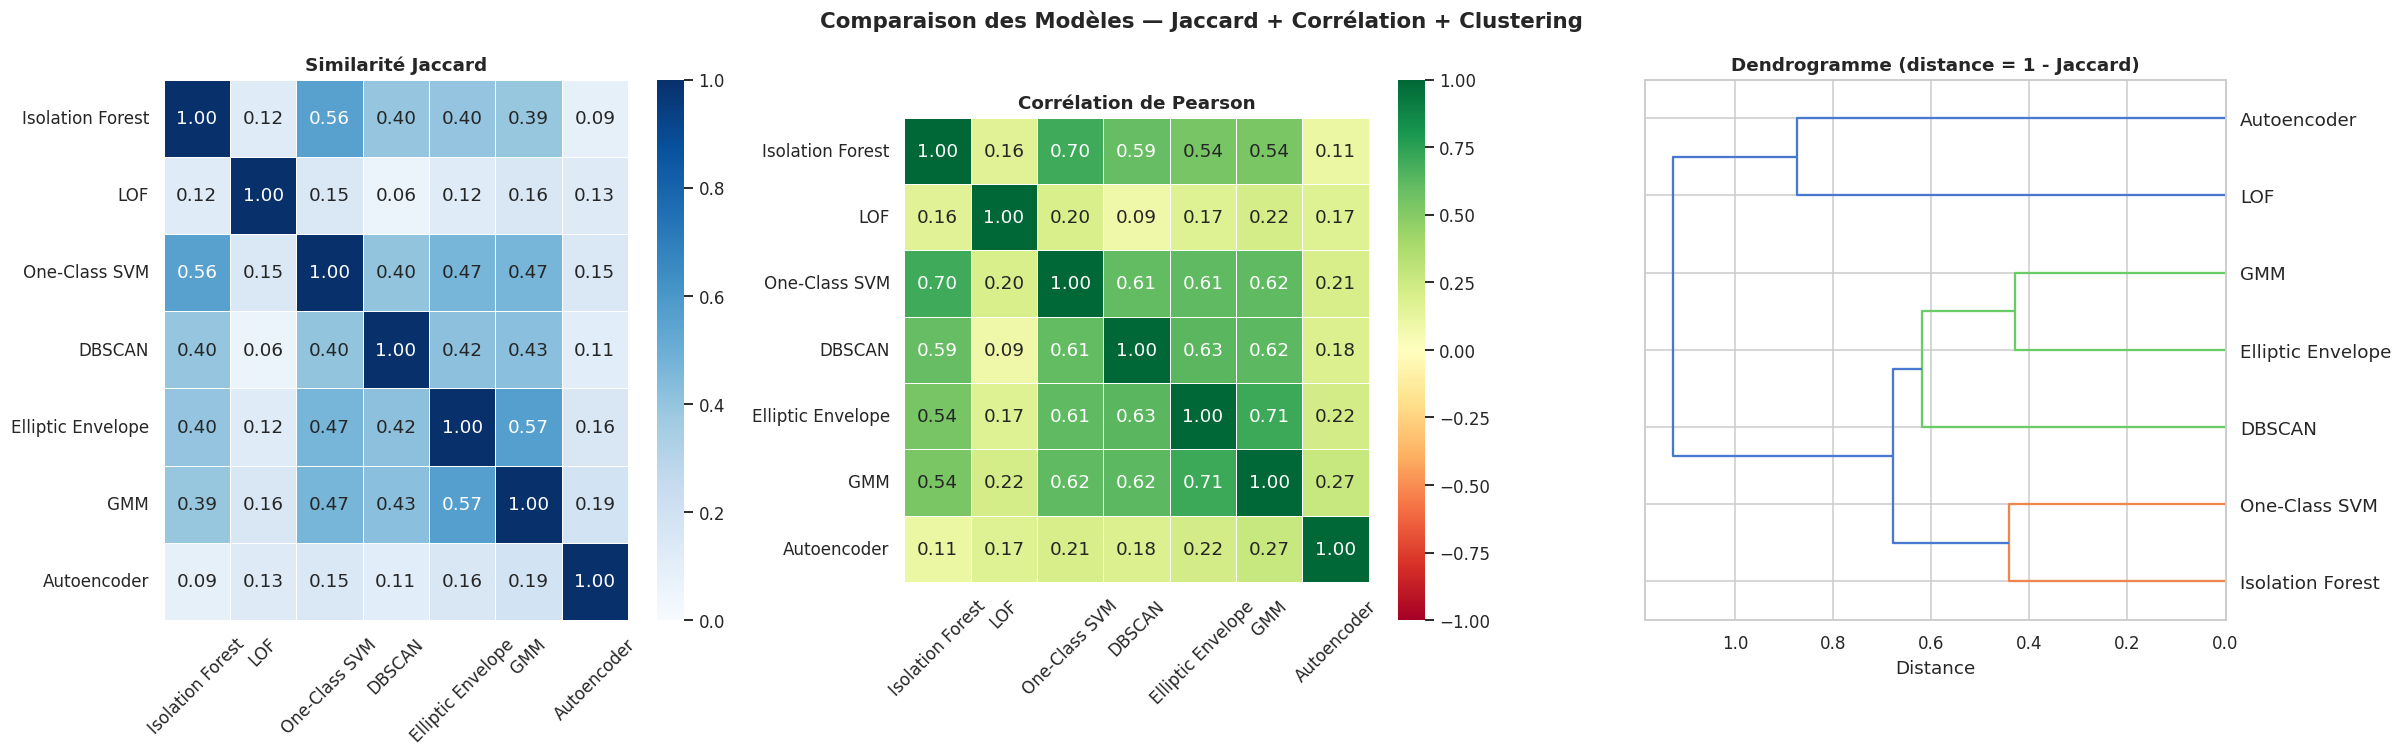

                A                 B  Jaccard  Pearson                 Relation
Elliptic Envelope               GMM   0.5700   0.7078               Redondants
 Isolation Forest     One-Class SVM   0.5577   0.6963               Redondants
    One-Class SVM Elliptic Envelope   0.4710   0.6148 Partiellement similaires
    One-Class SVM               GMM   0.4704   0.6154 Partiellement similaires
           DBSCAN               GMM   0.4257   0.6243 Partiellement similaires
           DBSCAN Elliptic Envelope   0.4209   0.6269 Partiellement similaires
    One-Class SVM            DBSCAN   0.4033   0.6067 Partiellement similaires
 Isolation Forest Elliptic Envelope   0.3996   0.5411 Partiellement similaires
 Isolation Forest            DBSCAN   0.3954   0.5940 Partiellement similaires
 Isolation Forest               GMM   0.3942   0.5362 Partiellement similaires
              GMM       Autoencoder   0.1886   0.2728          Complémentaires
              LOF               GMM   0.1558   0.218

In [14]:
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance  import squareform

modele_noms = list(anomalie_labels.keys())
n_m         = len(modele_noms)
labels_mat  = pd.DataFrame(anomalie_labels, index=df.index)

def jaccard(a, b):
    inter = (a & b).sum()
    union = (a | b).sum()
    return inter / union if union > 0 else 0.0

jacc_matrix = np.array([[jaccard(labels_mat[m1].astype(bool), labels_mat[m2].astype(bool))
                          for m2 in modele_noms] for m1 in modele_noms])
df_jacc = pd.DataFrame(jacc_matrix, index=modele_noms, columns=modele_noms).round(4)

corr_labels = labels_mat.corr(method='pearson')

dist_matrix = np.clip((1 - jacc_matrix + (1 - jacc_matrix).T) / 2, 0, None)
np.fill_diagonal(dist_matrix, 0)
Z = linkage(squareform(dist_matrix), method='ward')

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Comparaison des Modèles — Jaccard + Corrélation + Clustering',
             fontsize=14, fontweight='bold')
sns.heatmap(df_jacc, ax=axes[0], annot=True, fmt='.2f',
            cmap='Blues', vmin=0, vmax=1, linewidths=0.5)
axes[0].set_title('Similarité Jaccard', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(corr_labels, ax=axes[1], annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1, linewidths=0.5, square=True)
axes[1].set_title('Corrélation de Pearson', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

dendrogram(Z, labels=modele_noms, orientation='left',
           ax=axes[2], color_threshold=0.6 * max(Z[:, 2]))
axes[2].set_title('Dendrogramme (distance = 1 - Jaccard)', fontweight='bold')
axes[2].set_xlabel('Distance')

plt.tight_layout()
plt.show()

paires = [{'A': modele_noms[i], 'B': modele_noms[j],
           'Jaccard': round(jacc_matrix[i,j], 4),
           'Pearson': round(corr_labels.iloc[i,j], 4),
           'Relation': ('Redondants' if jacc_matrix[i,j] > 0.5
                        else 'Complémentaires' if jacc_matrix[i,j] < 0.2
                        else 'Partiellement similaires')}
          for i in range(n_m) for j in range(i+1, n_m)]
print(pd.DataFrame(paires).sort_values('Jaccard', ascending=False).to_string(index=False))

In [15]:
q90_conso        = df['consommation_kwh'].quantile(0.90)
mask_conso_elevee = df['consommation_kwh'] > q90_conso
mask_ecart_eleve  = (df['ecart_pct'].fillna(0).abs() > 20) if 'ecart_pct' in df.columns else mask_conso_elevee
mask_qos_degrade  = df['score_qos'] < qos_seuil
if 'stress_radio' in df.columns:
    mask_qos_degrade = mask_qos_degrade | (df['stress_radio'] > df['stress_radio'].quantile(0.70))

mask_type1 = mask_conso_elevee & mask_ecart_eleve
mask_type2 = mask_qos_degrade  & ~mask_conso_elevee
mask_type3 = mask_conso_elevee & mask_qos_degrade

types_par_modele = {}
for nom, lbl in anomalie_labels.items():
    lbl_s = pd.Series(lbl, index=df.index).astype(bool)
    n     = lbl_s.sum()
    if n == 0:
        types_par_modele[nom] = dict(n_anom=0,
            t1=0, t2=0, t3=0, t4=0); continue
    types_par_modele[nom] = {
        'n_anom': int(n),
        't1_%'  : round((lbl_s & mask_type1).sum() / n * 100, 1),
        't2_%'  : round((lbl_s & mask_type2).sum() / n * 100, 1),
        't3_%'  : round((lbl_s & mask_type3).sum() / n * 100, 1),
        't4_%'  : round((lbl_s & ~mask_type1 & ~mask_type2 & ~mask_type3).sum() / n * 100, 1),
    }

df_types = pd.DataFrame(types_par_modele).T
print(df_types.to_string())

type_vect = np.where(df['label_ensemble_score'] == 0, 'Normal',
            np.where(mask_type3.values, 'TYPE3 — Combinée',
            np.where(mask_type1.values, 'TYPE1 — Conso élevée',
            np.where(mask_type2.values, 'TYPE2 — QoS dégradée',
                                        'TYPE4 — Isolé'))))
df['type_anomalie'] = type_vect
print()
print(df['type_anomalie'].value_counts().to_string())

                     n_anom  t1_%  t2_%  t3_%  t4_%
Isolation Forest   101611.0  13.6  30.9  26.5  34.4
LOF                110161.0   1.5  36.4   8.6  54.2
One-Class SVM      104712.0  13.4  26.4  19.2  46.4
DBSCAN              46874.0  29.1  23.0  19.6  39.7
Elliptic Envelope  104814.0  13.9  19.4  15.7  56.7
GMM                 98251.0  14.2  30.8  15.2  45.6
Autoencoder         95176.0   0.7  31.1   3.6  65.0

type_anomalie
Normal                  1475647
TYPE4 — Isolé             42411
TYPE2 — QoS dégradée      28680
TYPE3 — Combinée          21832
TYPE1 — Conso élevée       8451


                  pct_detection_% valid_metier_% instabilite pval_stabilite score_stabilite overlap_ensemble_% type_dominant score_composite
Isolation Forest             6.44           27.6        0.05         0.2752           100.0               69.6          t4_%           70.65
One-Class SVM                6.64           24.1        0.04         0.2997           100.0               73.9          t4_%           70.28
GMM                          6.23           24.0        0.01         0.8908           100.0               50.9          t4_%           64.52
Elliptic Envelope            6.65           23.8        0.16         0.0001            98.4               49.3          t4_%           63.62
DBSCAN                       2.97           36.3         0.0         0.9712           100.0               43.9          t4_%           59.96
LOF                          6.99           12.7        0.36            0.0            96.4               17.4          t4_%           51.15
Autoencoder  

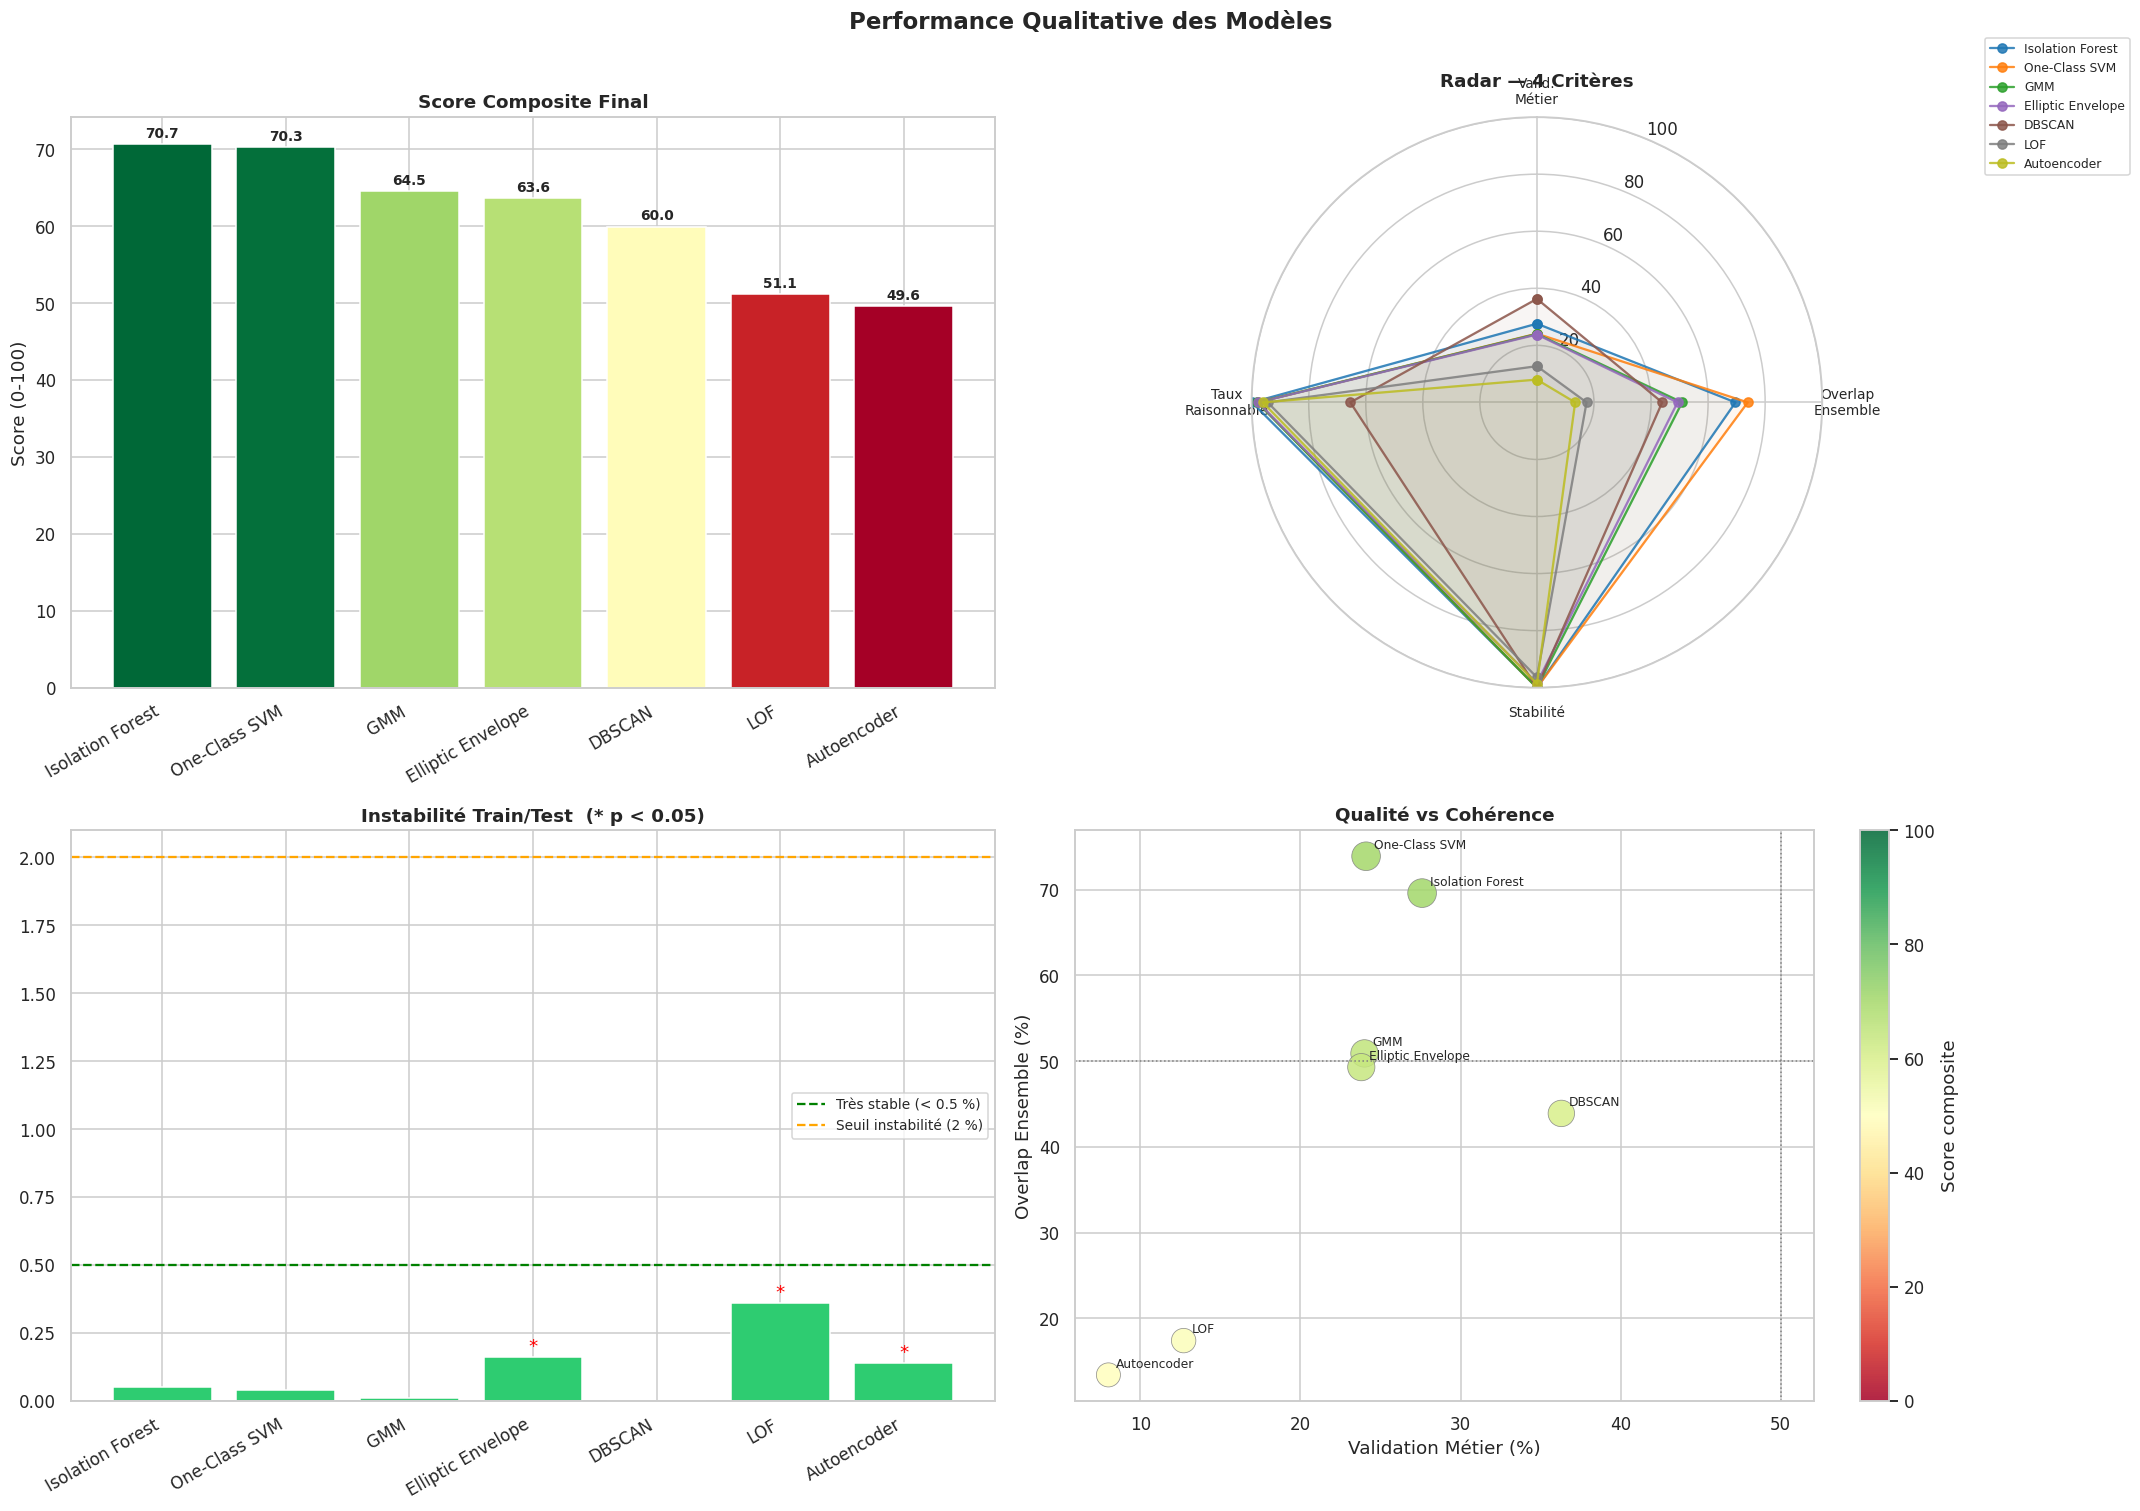


ranking final :
  # 1 ***  Isolation Forest        score= 70.7 | valid= 27.6% | overlap= 69.6% | instab=0.05% | pval=0.275
  # 2 ***  One-Class SVM           score= 70.3 | valid= 24.1% | overlap= 73.9% | instab=0.04% | pval=0.300
  # 3 ***  GMM                     score= 64.5 | valid= 24.0% | overlap= 50.9% | instab=0.01% | pval=0.891
  # 4 ***  Elliptic Envelope       score= 63.6 | valid= 23.8% | overlap= 49.3% | instab=0.16% | pval=0.000
  # 5 **   DBSCAN                  score= 60.0 | valid= 36.3% | overlap= 43.9% | instab=0.00% | pval=0.971
  # 6 **   LOF                     score= 51.1 | valid= 12.7% | overlap= 17.4% | instab=0.36% | pval=0.000
  # 7 **   Autoencoder             score= 49.6 | valid=  8.0% | overlap= 13.4% | instab=0.14% | pval=0.001


In [16]:
# Test de proportion (z-test bilatéral) pour valider si l'écart train/test
# est statistiquement significatif (alpha = 0.05).

def ztest_proportion(lbl_arr, mask_train):
    p_tr = lbl_arr[mask_train].mean()
    p_te = lbl_arr[~mask_train].mean()
    n_tr = mask_train.sum()
    n_te = (~mask_train).sum()
    count = np.array([int(p_tr * n_tr), int(p_te * n_te)])
    nobs  = np.array([n_tr, n_te])
    _, pval = proportions_ztest(count, nobs)
    return pval

labels_ens = pd.Series(df['label_ensemble_score'].values, index=df.index).astype(bool)
labels_mat_f = pd.DataFrame(anomalie_labels, index=df.index)
n_tr = len(df_train)

perf_finale = {}
for nom, lbl in anomalie_labels.items():
    lbl_s   = pd.Series(lbl, index=df.index).astype(bool)
    n_anom  = lbl_s.sum()

    pct_anom  = lbl_s.mean() * 100
    pct_valid = validation_metier.get(nom, {}).get('score_validation_global', 0.0)

    mask_train  = (df['annee'] < TEST_YEAR).values

    pct_tr      = lbl_s[mask_train].mean() * 100
    pct_te      = lbl_s[~mask_train].mean() * 100
    instabilite = abs(pct_tr - pct_te)

    pval_stab   = ztest_proportion(lbl_s.values, mask_train)
    score_stab  = 100.0 if pval_stab > 0.05 else max(0, 100 - instabilite * 10)

    inter       = (lbl_s & labels_ens).sum()
    union       = (lbl_s | labels_ens).sum()
    jaccard_ens = (inter / union * 100) if union > 0 else 0.0

    type_dict    = {k: v for k, v in types_par_modele.get(nom, {}).items() if k.endswith('%')}
    type_dominant = max(type_dict, key=type_dict.get) if n_anom > 0 and type_dict else 'N/A'

    taux_score  = max(0, min(100, 100 - abs(pct_anom - CONTAMINATION * 100) * 10))
    score_composite = (
        pct_valid   * 0.30 +
        jaccard_ens * 0.25 +
        score_stab  * 0.25 +
        taux_score  * 0.20
    )
    perf_finale[nom] = {
        'pct_detection_%'   : round(pct_anom, 2),
        'valid_metier_%'    : round(pct_valid, 1),
        'instabilite'       : round(instabilite, 2),
        'pval_stabilite'    : round(pval_stab, 4),
        'score_stabilite'   : round(score_stab, 1),
        'overlap_ensemble_%': round(jaccard_ens, 1),
        'type_dominant'     : type_dominant,
        'score_composite'   : round(score_composite, 2),
    }

df_perf = pd.DataFrame(perf_finale).T.sort_values('score_composite', ascending=False)
print(df_perf.to_string())
fig = plt.figure(figsize=(20, 14))
fig.suptitle('Performance Qualitative des Modèles', fontsize=15, fontweight='bold')
modeles_p = df_perf.index.tolist()
cmap_pf   = plt.cm.RdYlGn
norm_pf   = plt.Normalize(df_perf['score_composite'].min(), df_perf['score_composite'].max())
colors_pf = [cmap_pf(norm_pf(s)) for s in df_perf['score_composite'].values]

ax1 = fig.add_subplot(2, 2, 1)
bars1 = ax1.bar(modeles_p, df_perf['score_composite'].values, color=colors_pf, edgecolor='white')
ax1.set_title('Score Composite Final', fontweight='bold')
ax1.set_ylabel('Score (0-100)')
ax1.set_xticklabels(modeles_p, rotation=30, ha='right')
for bar, val in zip(bars1, df_perf['score_composite'].values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2 = fig.add_subplot(2, 2, 2, polar=True)
categories = ['Valid.\nMétier', 'Overlap\nEnsemble', 'Stabilité', 'Taux\nRaisonnable']
N_cat  = len(categories)
angles = [n / float(N_cat) * 2 * np.pi for n in range(N_cat)] + [0]
ax2.set_theta_offset(np.pi / 2)
ax2.set_theta_direction(-1)
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories, size=9)
ax2.set_ylim(0, 100)
cmap_r = plt.cm.tab10
for idx_r, nom in enumerate(modeles_p):
    row_r   = df_perf.loc[nom]
    taux_r  = max(0, min(100, 100 - abs(row_r['pct_detection_%'] - CONTAMINATION * 100) * 10))
    vals_r  = [row_r['valid_metier_%'], row_r['overlap_ensemble_%'], row_r['score_stabilite'], taux_r]
    vals_r += vals_r[:1]
    color_r = cmap_r(idx_r / max(len(modeles_p), 1))
    ax2.plot(angles, vals_r, 'o-', lw=1.5, label=nom, color=color_r, alpha=0.85)
    ax2.fill(angles, vals_r, alpha=0.06, color=color_r)
ax2.set_title('Radar — 4 Critères', fontweight='bold', pad=20)
ax2.legend(loc='upper right', bbox_to_anchor=(1.55, 1.15), fontsize=8)

ax3 = fig.add_subplot(2, 2, 3)
cols_inst = ['#2ecc71' if v < 0.5 else '#f39c12' if v < 2.0 else '#e74c3c'
             for v in df_perf['instabilite'].values]
ax3.bar(modeles_p, df_perf['instabilite'].values, color=cols_inst, edgecolor='white')
ax3.axhline(0.5, color='green',  ls='--', lw=1.5, label='Très stable (< 0.5 %)')
ax3.axhline(2.0, color='orange', ls='--', lw=1.5, label='Seuil instabilité (2 %)')
for i, (m, row) in enumerate(df_perf.iterrows()):
    star = '*' if row['pval_stabilite'] < 0.05 else ''
    ax3.text(i, row['instabilite'] + 0.02, star, ha='center', fontsize=12, color='red')
ax3.set_title('Instabilité Train/Test  (* p < 0.05)', fontweight='bold')
ax3.set_xticklabels(modeles_p, rotation=30, ha='right')
ax3.legend(fontsize=9)

ax4 = fig.add_subplot(2, 2, 4)
sc_x = df_perf['valid_metier_%'].values
sc_y = df_perf['overlap_ensemble_%'].values
sc_s = df_perf['score_composite'].values.astype(float) * 5
sc   = ax4.scatter(sc_x, sc_y, s=sc_s, c=df_perf['score_composite'].values,
                   cmap='RdYlGn', alpha=0.85, edgecolors='grey', linewidth=0.5,
                   vmin=0, vmax=100)
for i, nom in enumerate(modeles_p):
    ax4.annotate(nom, (sc_x[i], sc_y[i]),
                 textcoords='offset points', xytext=(5, 5), fontsize=8)
ax4.set_xlabel('Validation Métier (%)')
ax4.set_ylabel('Overlap Ensemble (%)')
ax4.set_title('Qualité vs Cohérence', fontweight='bold')
plt.colorbar(sc, ax=ax4, label='Score composite')
ax4.axhline(50, color='grey', ls=':', lw=1)
ax4.axvline(50, color='grey', ls=':', lw=1)

plt.tight_layout()
plt.show()

df_perf.to_csv('outputs/performance_qualitative_modeles.csv')
print('\nranking final :')
for rank, (nom, row) in enumerate(df_perf.iterrows(), 1):
    star = '***' if row['score_composite'] >= 60 else '** ' if row['score_composite'] >= 40 else '*  '
    print(f"  #{rank:>2} {star}  {nom:<22}  score={row['score_composite']:5.1f}"
          f" | valid={row['valid_metier_%']:5.1f}%"
          f" | overlap={row['overlap_ensemble_%']:5.1f}%"
          f" | instab={row['instabilite']:4.2f}%"
          f" | pval={row['pval_stabilite']:.3f}")

## Phase 5g — Courbes Precision-Recall par Modèle
Comparaison des capacités de ranking sur la référence métier (`ecart_pct > 30 %`).

Référence métier : 61,347 positifs / 1,577,021 total (3.89 %)


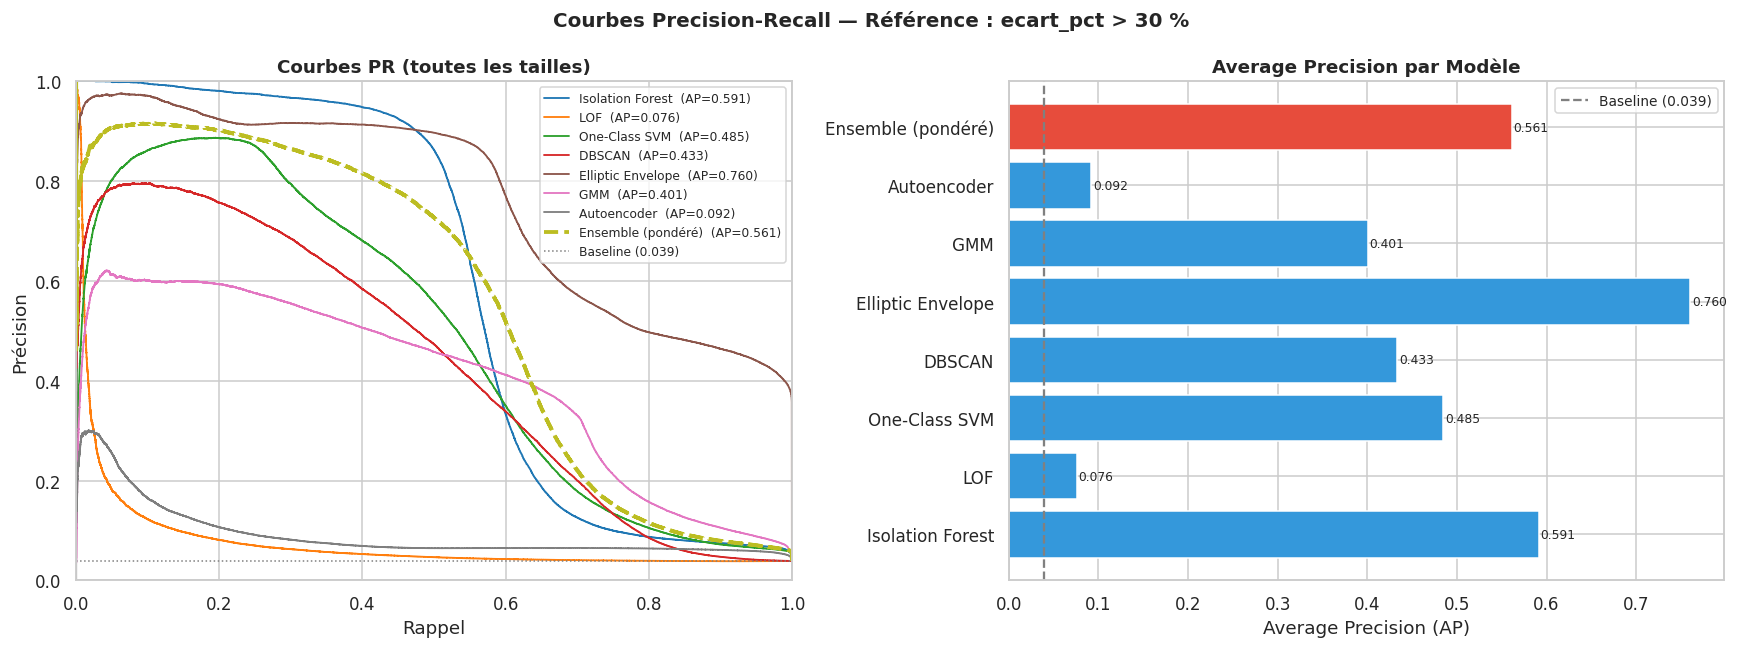


Meilleur AP : Elliptic Envelope  (AP = 0.7605)
AP summary :
  Elliptic Envelope          0.7605
  Isolation Forest           0.5912
  Ensemble (pondéré)         0.5610
  One-Class SVM              0.4846
  DBSCAN                     0.4333
  GMM                        0.4008
  Autoencoder                0.0918
  LOF                        0.0757


In [17]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Référence binaire : ecart_pct > 30 %
y_ref = (df['ecart_pct'].fillna(0).abs() > 30).astype(int).values

# Vérifier qu'il y a assez de positifs pour tracer les courbes
n_pos = y_ref.sum()
print(f'Référence métier : {n_pos:,} positifs / {len(y_ref):,} total ({n_pos/len(y_ref)*100:.2f} %)')

# Collecter les scores continus normalisés pour chaque modèle + ensembles
pr_scores = {}
for nom in df_scores.columns:
    pr_scores[nom] = df_scores[nom].values
pr_scores['Ensemble (pondéré)'] = df['anomalie_score_ensemble'].values

ap_summary = {}
for nom, sc in pr_scores.items():
    if y_ref.sum() == 0:
        break
    ap_summary[nom] = average_precision_score(y_ref, sc)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Courbes Precision-Recall — Référence : ecart_pct > 30 %',
             fontsize=13, fontweight='bold')

cmap_pr = plt.cm.tab10
for idx_pr, (nom, sc) in enumerate(pr_scores.items()):
    if y_ref.sum() == 0:
        break
    prec, rec, _ = precision_recall_curve(y_ref, sc)
    ap = ap_summary.get(nom, 0)
    lw  = 2.5 if 'Ensemble' in nom else 1.2
    ls  = '--' if 'Ensemble' in nom else '-'
    axes[0].plot(rec, prec, lw=lw, ls=ls,
                 color=cmap_pr(idx_pr / max(len(pr_scores), 1)),
                 label=f'{nom}  (AP={ap:.3f})')

baseline_pr = y_ref.mean()
axes[0].axhline(baseline_pr, color='grey', ls=':', lw=1, label=f'Baseline ({baseline_pr:.3f})')
axes[0].set_xlabel('Rappel')
axes[0].set_ylabel('Précision')
axes[0].set_title('Courbes PR (toutes les tailles)', fontweight='bold')
axes[0].legend(fontsize=8, loc='upper right')
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)

# Barre AP
if ap_summary:
    noms_ap  = list(ap_summary.keys())
    vals_ap  = list(ap_summary.values())
    cols_ap  = ['#e74c3c' if 'Ensemble' in n else '#3498db' for n in noms_ap]
    bars_ap  = axes[1].barh(noms_ap, vals_ap, color=cols_ap, edgecolor='white')
    axes[1].axvline(baseline_pr, color='grey', ls='--', lw=1.5,
                    label=f'Baseline ({baseline_pr:.3f})')
    axes[1].set_xlabel('Average Precision (AP)')
    axes[1].set_title('Average Precision par Modèle', fontweight='bold')
    axes[1].legend(fontsize=9)
    for bar, v in zip(bars_ap, vals_ap):
        axes[1].text(v + 0.002, bar.get_y() + bar.get_height()/2,
                     f'{v:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('outputs/precision_recall_modeles.png', dpi=110, bbox_inches='tight')
plt.show()

if ap_summary:
    best_pr = max(ap_summary, key=ap_summary.get)
    print(f'\nMeilleur AP : {best_pr}  (AP = {ap_summary[best_pr]:.4f})')
    print('AP summary :')
    for n, v in sorted(ap_summary.items(), key=lambda x: -x[1]):
        print(f'  {n:<26} {v:.4f}')


## Phase 5h — Visualisation t-SNE des Anomalies
Projection 2-D d'un sous-échantillon stratifié pour vérifier la séparation normale / anomalie dans l'espace des features.

t-SNE sur 4,000 points  (2000 anomalies, 2000 normaux) ...
  terminé en 21.9s


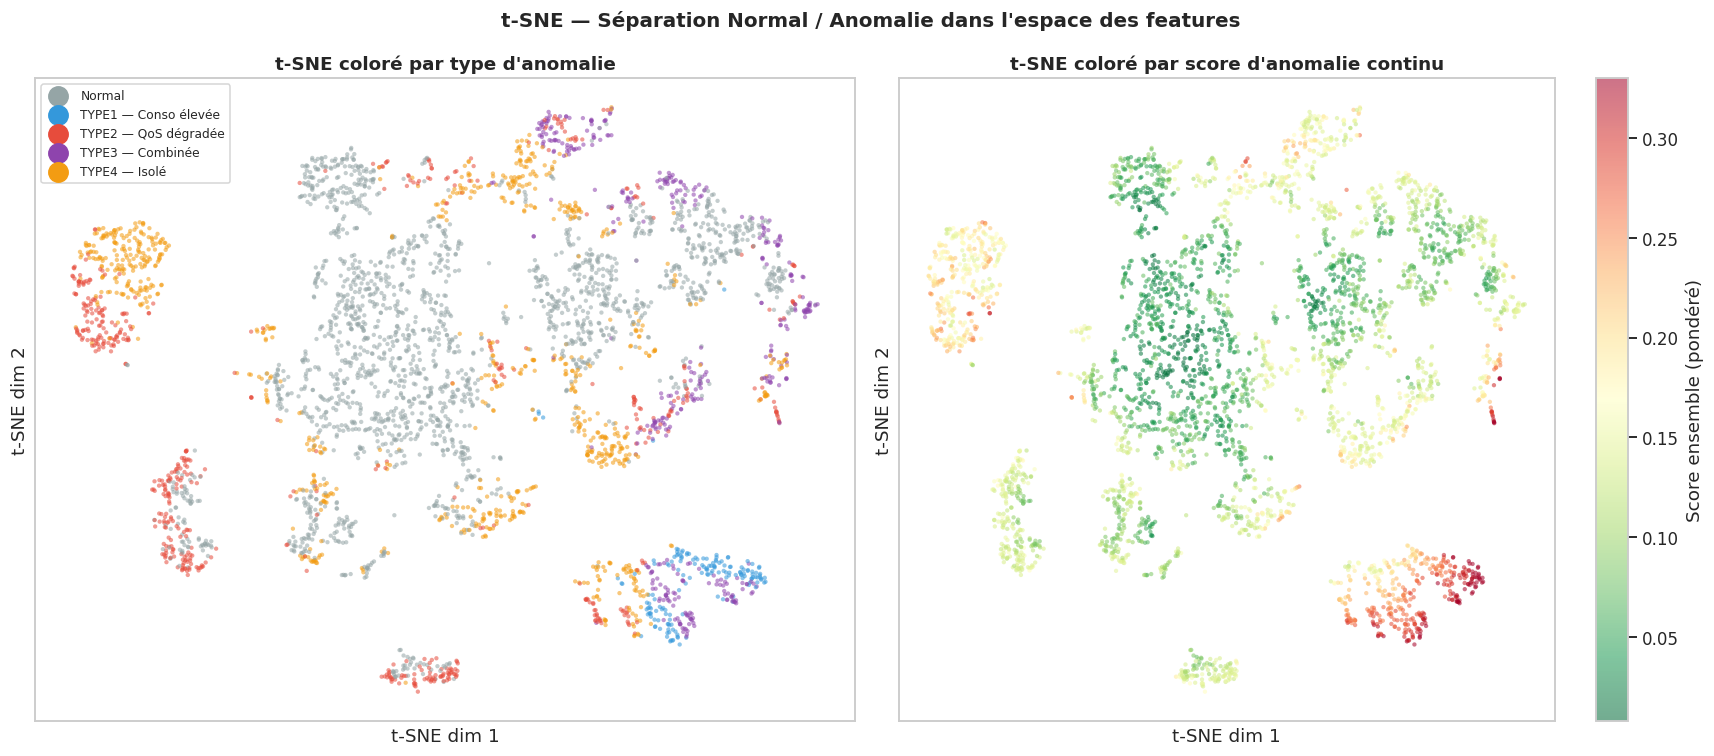

Silhouette score (t-SNE, normal vs anomalie) : 0.0779
  > 0.5  = bonne séparation
  0.25–0.5 = séparation partielle (attendu pour détection non supervisée)
  < 0.25 = anomalies diffuses (inspecter le consensus_votes)


In [18]:
from sklearn.manifold import TSNE

# Sous-échantillon stratifié : équilibre normal / anomalie pour un t-SNE lisible
N_TSNE      = min(4_000, len(df))
rng_tsne    = np.random.RandomState(42)

idx_anom_ts = np.where(df['label_ensemble_score'].values == 1)[0]
idx_norm_ts = np.where(df['label_ensemble_score'].values == 0)[0]

n_a = min(N_TSNE // 2, len(idx_anom_ts))
n_n = min(N_TSNE - n_a, len(idx_norm_ts))
idx_tsne = np.concatenate([
    rng_tsne.choice(idx_anom_ts, n_a, replace=False),
    rng_tsne.choice(idx_norm_ts, n_n, replace=False),
])
idx_tsne = np.sort(idx_tsne)

X_tsne_in = X_all_std[idx_tsne]
y_tsne    = df['label_ensemble_score'].values[idx_tsne]

print(f't-SNE sur {len(idx_tsne):,} points  ({n_a} anomalies, {n_n} normaux) ...')
t0_ts = time.time()
tsne  = TSNE(n_components=2, perplexity=40, learning_rate='auto',
             init='pca', random_state=42, n_jobs=-1)
Z_ts  = tsne.fit_transform(X_tsne_in)
print(f'  terminé en {time.time()-t0_ts:.1f}s')

# Couleur par type d'anomalie si disponible
if 'type_anomalie' in df.columns:
    type_tsne = df['type_anomalie'].values[idx_tsne]
    type_cats = ['Normal', 'TYPE1 — Conso élevée', 'TYPE2 — QoS dégradée',
                 'TYPE3 — Combinée', 'TYPE4 — Isolé']
    palette_t = {'Normal': '#95a5a6',
                 'TYPE1 — Conso élevée':  '#3498db',
                 'TYPE2 — QoS dégradée':  '#e74c3c',
                 'TYPE3 — Combinée':      '#8e44ad',
                 'TYPE4 — Isolé':         '#f39c12'}
    color_tsne = [palette_t.get(t, '#7f8c8d') for t in type_tsne]
    legend_items = type_cats
else:
    color_tsne   = ['#e74c3c' if y == 1 else '#95a5a6' for y in y_tsne]
    legend_items  = ['Normal', 'Anomalie']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('t-SNE — Séparation Normal / Anomalie dans l\'espace des features',
             fontsize=13, fontweight='bold')

# t-SNE coloré par type d'anomalie
axes[0].scatter(Z_ts[:, 0], Z_ts[:, 1], c=color_tsne,
                s=8, alpha=0.55, linewidths=0)
if 'type_anomalie' in df.columns:
    for lbl_t, col_t in palette_t.items():
        axes[0].scatter([], [], c=col_t, s=40, label=lbl_t)
else:
    for lbl_t, col_t in zip(['Normal', 'Anomalie'], ['#95a5a6', '#e74c3c']):
        axes[0].scatter([], [], c=col_t, s=40, label=lbl_t)
axes[0].legend(fontsize=8, markerscale=2, loc='best')
axes[0].set_title('t-SNE coloré par type d\'anomalie', fontweight='bold')
axes[0].set_xlabel('t-SNE dim 1'); axes[0].set_ylabel('t-SNE dim 2')
axes[0].set_xticks([]); axes[0].set_yticks([])

# t-SNE coloré par score d'ensemble continu
sc_ts = df['anomalie_score_ensemble'].values[idx_tsne]
sc_plot = axes[1].scatter(Z_ts[:, 0], Z_ts[:, 1], c=sc_ts,
                           cmap='RdYlGn_r', s=8, alpha=0.55, linewidths=0,
                           vmin=sc_ts.min(), vmax=np.percentile(sc_ts, 99))
plt.colorbar(sc_plot, ax=axes[1], label='Score ensemble (pondéré)')
axes[1].set_title('t-SNE coloré par score d\'anomalie continu', fontweight='bold')
axes[1].set_xlabel('t-SNE dim 1'); axes[1].set_ylabel('t-SNE dim 2')
axes[1].set_xticks([]); axes[1].set_yticks([])

plt.tight_layout()
plt.savefig('outputs/tsne_anomalies.png', dpi=110, bbox_inches='tight')
plt.show()

# Statistiques de séparation
from sklearn.metrics import silhouette_score as _sil
if n_a > 10 and n_n > 10 and len(set(y_tsne)) > 1:
    sil = _sil(Z_ts, y_tsne, sample_size=min(2000, len(Z_ts)), random_state=42)
    print(f'Silhouette score (t-SNE, normal vs anomalie) : {sil:.4f}')
    print('  > 0.5  = bonne séparation')
    print('  0.25–0.5 = séparation partielle (attendu pour détection non supervisée)')
    print('  < 0.25 = anomalies diffuses (inspecter le consensus_votes)')


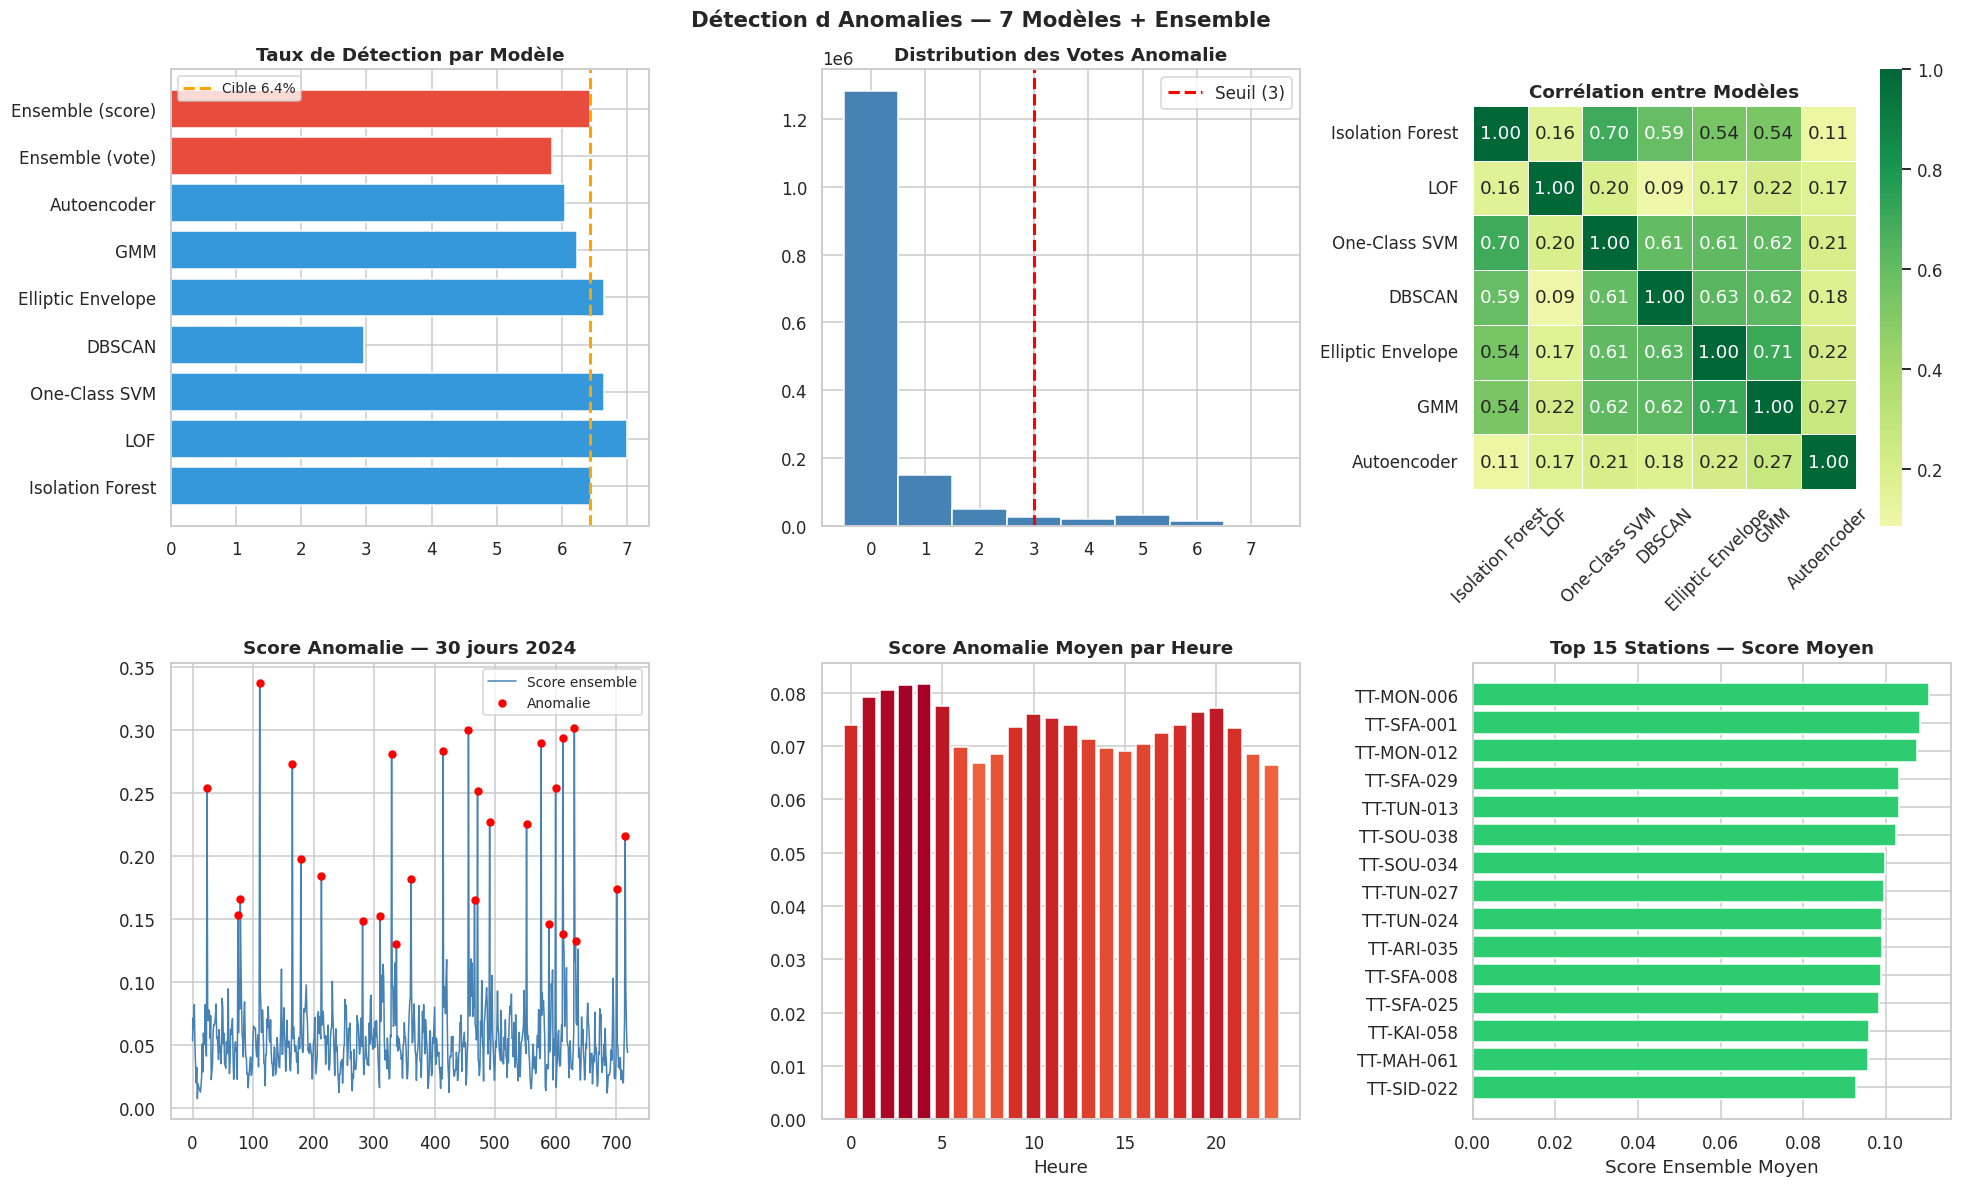

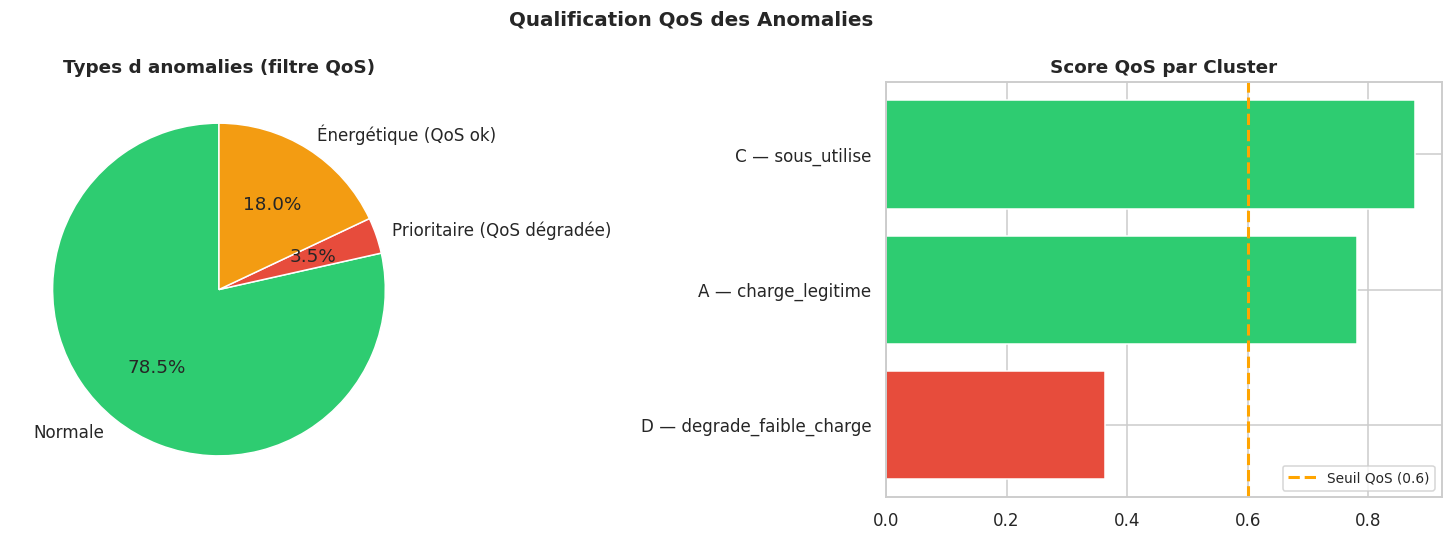

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Détection d Anomalies — 7 Modèles + Ensemble', fontsize=14, fontweight='bold')

noms  = list(resultats_qual.keys()) + ['Ensemble (vote)', 'Ensemble (score)']
pctes = ([resultats_qual[n]['pct_anomalies'] for n in list(resultats_qual.keys())] +
         [label_vote.mean()*100, label_pondere.mean()*100])
cols  = ['#3498db'] * len(resultats_qual) + ['#e74c3c', '#e74c3c']
axes[0,0].barh(noms, pctes, color=cols, edgecolor='white')
axes[0,0].axvline(CONTAMINATION * 100, color='orange', ls='--', lw=2,
                  label=f'Cible {CONTAMINATION*100:.1f}%')
axes[0,0].set_title('Taux de Détection par Modèle', fontweight='bold')
axes[0,0].legend(fontsize=9)

axes[0,1].hist(df['nb_votes_anomalie'], bins=range(0, len(anomalie_labels)+2),
               color='steelblue', edgecolor='white', align='left')
axes[0,1].axvline(seuil_vote, color='red', lw=2, ls='--', label=f'Seuil ({seuil_vote})')
axes[0,1].set_title('Distribution des Votes Anomalie', fontweight='bold')
axes[0,1].legend()

corr_lbl = labels_matrix.corr()
sns.heatmap(corr_lbl, ax=axes[0,2], annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, square=True, linewidths=0.5)
axes[0,2].set_title('Corrélation entre Modèles', fontweight='bold')
axes[0,2].tick_params(axis='x', rotation=45)

df_ex = df[df['annee'] == TEST_YEAR].head(24*30).copy()
mask_an  = df_ex['label_ensemble_score'] == 1
axes[1,0].plot(range(len(df_ex)), df_ex['anomalie_score_ensemble'].values,
               color='steelblue', lw=1, label='Score ensemble')
axes[1,0].scatter(np.where(mask_an)[0],
                  df_ex.loc[mask_an, 'anomalie_score_ensemble'].values,
                  color='red', s=20, zorder=5, label='Anomalie')
axes[1,0].set_title(f'Score Anomalie — 30 jours {TEST_YEAR}', fontweight='bold')
axes[1,0].legend(fontsize=9)

score_h = df.groupby('heure')['anomalie_score_ensemble'].mean()
axes[1,1].bar(score_h.index, score_h.values,
              color=plt.cm.RdYlGn_r(score_h.values / score_h.max()))
axes[1,1].set_title('Score Anomalie Moyen par Heure', fontweight='bold')
axes[1,1].set_xlabel('Heure')

score_st = df.groupby('station_id').agg(
    score_moy   = ('anomalie_score_ensemble', 'mean'),
    gouvernorat = ('gouvernorat', 'first'),
).sort_values('score_moy', ascending=False).head(15)
cols_st = ['#e74c3c' if s > 0.5 else '#f39c12' if s > 0.3 else '#2ecc71'
           for s in score_st['score_moy']]
axes[1,2].barh(score_st.index[::-1], score_st['score_moy'][::-1], color=cols_st[::-1])
axes[1,2].set_title('Top 15 Stations — Score Moyen', fontweight='bold')
axes[1,2].set_xlabel('Score Ensemble Moyen')

plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle('Qualification QoS des Anomalies', fontsize=13, fontweight='bold')

n_normale  = len(df) - df['anomalie_prioritaire'].sum() - df['anomalie_energetique_pure'].sum()
ax2[0].pie(
    [n_normale, df['anomalie_prioritaire'].sum(), df['anomalie_energetique_pure'].sum()],
    labels=['Normale', 'Prioritaire (QoS dégradée)', 'Énergétique (QoS ok)'],
    colors=['#2ecc71', '#e74c3c', '#f39c12'], autopct='%1.1f%%', startangle=90)
ax2[0].set_title('Types d anomalies (filtre QoS)', fontweight='bold')

if 'cluster_nom' in df.columns:
    qos_cl = df.groupby('cluster_nom')['score_qos'].mean().sort_values()
    cols_cl = ['#e74c3c' if v < qos_seuil else '#2ecc71' for v in qos_cl.values]
    ax2[1].barh(qos_cl.index, qos_cl.values, color=cols_cl)
    ax2[1].axvline(qos_seuil, color='orange', ls='--', lw=2, label=f'Seuil QoS ({qos_seuil})')
    ax2[1].set_title('Score QoS par Cluster', fontweight='bold')
    ax2[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

In [20]:
for nom, lbl in anomalie_labels.items():
    safe = nom.lower().replace(' ', '_').replace('-', '_')
    df[f'anom_{safe}'] = lbl

score_station_full = df.groupby('station_id').agg(
    pct_anomalie_ensemble    = ('label_ensemble_score', 'mean'),
    score_moy_ensemble       = ('anomalie_score_ensemble', 'mean'),
    nb_votes_moy             = ('nb_votes_anomalie', 'mean'),
    pct_anomalie_prioritaire = ('anomalie_prioritaire', 'mean'),
    pct_anomalie_energetique = ('anomalie_energetique_pure', 'mean'),
    score_qos_moy            = ('score_qos', 'mean'),
    cluster_id_mode          = ('cluster_id', lambda x: x.mode()[0]),
    conso_moy                = ('consommation_kwh', 'mean'),
    eei_moy                  = ('eei', 'mean'),
    technologie              = ('technologie', 'first'),
    gouvernorat              = ('gouvernorat', 'first'),
    type_zone                = ('type_zone', 'first'),
).reset_index()

score_station_full['score_criticite'] = (
    score_station_full['pct_anomalie_ensemble'] * 0.50 +
    score_station_full['score_moy_ensemble']    * 0.30 +
    (score_station_full['nb_votes_moy'] / len(anomalie_labels)) * 0.20
).round(4)

score_station_full['categorie'] = pd.cut(
    score_station_full['score_criticite'],
    bins   = [0, 0.05, 0.15, 1.0],
    labels = ['EFFICACE', 'ATTENTION', 'CRITIQUE']
)

df.to_parquet('outputs/df_avec_anomalies.parquet', index=False)
score_station_full.to_parquet('outputs/score_stations.parquet', index=False)

artefacts = {
    'iso_f'        : iso_f,
    'lof'          : lof,
    'oc_svm'       : oc_svm,
    'ee'           : ee,
    'gmm'          : gmm,
    'kmeans'       : kmeans,
    'scaler_std'   : scaler_std,
    'scaler_rob'   : scaler_rob,
    'scaler_clust' : scaler_clust,
    'pca_db'       : pca_db,
    'seuil_gmm'    : seuil_gmm,
    'seuil_ae'     : seuil_ae,
    'poids'        : POIDS,
    'contamination': CONTAMINATION,
    'features'     : ANOM_FEATURES,
    'cols_cluster' : cols_cluster,
    'qos_seuil'    : qos_seuil,
}
if HAS_TF:
    ae.save('outputs/autoencoder.keras')
else:
    artefacts['pca_ae'] = pca_ae_model

joblib.dump(artefacts, 'outputs/modeles_anomalie.joblib', compress=3)

with open('outputs/resultats_anomalie.json', 'w') as f:
    json.dump({k: {k2: str(v2) for k2, v2 in v.items()} for k, v in resultats_qual.items()},
              f, indent=2, ensure_ascii=False)

print('outputs/df_avec_anomalies.parquet')
print('outputs/score_stations.parquet')
print('outputs/modeles_anomalie.joblib')
if HAS_TF:
    print('outputs/autoencoder.keras')
print('outputs/resultats_anomalie.json')
print('-> NB3 prêt')

outputs/df_avec_anomalies.parquet
outputs/score_stations.parquet
outputs/modeles_anomalie.joblib
outputs/autoencoder.keras
outputs/resultats_anomalie.json
-> NB3 prêt
